# **BrainHack 2026**

## Table of contents<a id='toc0_'></a>    

- [Setup](#toc2_)    
  - [Install](#toc2_1_)    
    - [For developers](#toc2_1_1_)    
    - [For users](#toc2_1_2_)    
    - [Optional](#toc2_1_3_)    
  - [Imports](#toc2_2_)    
  - [Overview](#toc2_3_)    
    - [Meta](#toc2_3_1_)    
      - [Signal](#toc2_3_1_1_)    
      - [CompositeDictionary](#toc2_3_1_2_)    
      - [Duration](#toc2_3_1_3_)    
      - [Frequency](#toc2_3_1_4_)    
      - [AngularFrequency](#toc2_3_1_5_)    
      - [Angle](#toc2_3_1_6_)    
    - [Pulse](#toc2_3_2_)    
    - [Sequence](#toc2_3_3_)    
    - [System](#toc2_3_4_)    
      - [Lineshapes](#toc2_3_4_1_)    
    - [Simulator](#toc2_3_5_)    
    - [Corrector](#toc2_3_6_)    
      - [InterpolantDictionary](#toc2_3_6_1_)    
    - [Trajector - WIP](#toc2_3_7_)    
- [Applications](#toc3_)    
  - [Simulating a single experiment](#toc3_1_)    
    - [Using the `brainhack.simulator.Simulator` class](#toc3_1_1_)    
    - [Using the `brainhack.run.SingleRun` function](#toc3_1_2_)    
      - [Hand parametrized](#toc3_1_2_1_)    
      - [Using a configuration object](#toc3_1_2_2_)    
      - [From the command line](#toc3_1_2_3_)    
    - [Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc3_1_3_)    
      - [Manual Computation](#toc3_1_3_1_)    
      - [Using `brainhack.meta.CompositeSignal`](#toc3_1_3_2_)    
    - [Example: Computing steady-state signals at every readout](#toc3_1_4_)    
      - [Manual computation](#toc3_1_4_1_)    
      - [Using `brainhack.trajector.Trajector`](#toc3_1_4_2_)    
        - [Timing difference using `stable=True`](#toc3_1_4_2_1_)    
        - [Value difference using `stable=True`](#toc3_1_4_2_2_)    
    - [Example: Point Spread Function (PSF) - WIP](#toc3_1_5_)    
  - [Simulating many experiments](#toc3_2_)    
    - [Using the `brainhack.run.GridRuns` function](#toc3_2_1_)    
    - [Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc3_2_2_)    
    - [Example: $\mathrm{B}_1^+$ correction](#toc3_2_3_)    
      - [Manual computation](#toc3_2_3_1_)    
      - [Using `brainhack.corrector.Corrector`](#toc3_2_3_2_)    
  - [Visualization](#toc3_3_)    
    - [Example: $\mathrm{B}_1^+$ correction](#toc3_3_1_)    
      - [1-Dim $\mathrm{B}_1^+$ correction](#toc3_3_1_1_)    
      - [N-Dim $\mathrm{B}_1^+$ correction](#toc3_3_1_2_)    
      - [Real-world data](#toc3_3_1_3_)    
    - [Example: Steady-state signal with respect to readout](#toc3_3_2_)    
    - [Exmple: PSF - WIP](#toc3_3_3_)    
  - [Advanced](#toc3_4_)    
    - [Sensivity analysis - WIP](#toc3_4_1_)    
      - [Using fixed parameter vectors](#toc3_4_1_1_)    
      - [Using distribution sampling](#toc3_4_1_2_)    
- [Additional Information](#toc4_)    
  - [Configuration files](#toc4_1_)    
    - [Default configurations](#toc4_1_1_)    
      - [3 Teslas](#toc4_1_1_1_)    
      - [7 Teslas](#toc4_1_1_2_)    
    - [Custom configurations](#toc4_1_2_)    
      - [In a live environment](#toc4_1_2_1_)    
      - [Stored on file](#toc4_1_2_2_)    
  - [Loggers](#toc4_2_)    
  - [The `brainhack.meta.CompositeDictionary` class](#toc4_3_)    
  - [Optimizing `brainhack.run.GridRuns` runtime](#toc4_4_)    
  - [Test suite](#toc4_5_)    
  - [Contributing new features - WIP](#toc4_6_)    
    - [Adding new modules](#toc4_6_1_)    
    - [Modifying existing modules](#toc4_6_2_)    
- [Notes](#toc5_)    
- [To do](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Setup](#toc0_)

## <a id='toc2_1_'></a>[Install](#toc0_)

### <a id='toc2_1_1_'></a>[For developers](#toc0_)
- `NumPy`
- `SciPy`
- `PyYAML`
- `Coverage`

```bash
pip install numpy scipy pyyaml coverage
# or
conda install numpy scipy pyyaml coverage
```

Install `brainhack` in edit mode:
```bash
cd brainhack
pip install -e .
```

### <a id='toc2_1_2_'></a>[For users](#toc0_)
- `NumPy`
- `SciPy`
- `PyYAML`

```bash
pip install numpy scipy pyyaml
# or
conda install numpy scipy pyyaml
```

Install `brainhack` in normal mode:
```bash
cd brainhack
pip install .
```

### <a id='toc2_1_3_'></a>[Optional](#toc0_)
- `Matplotlib`
- `Jupyter`

```bash
pip install matplotlib jupyter
# or
conda install matplotlib jupyter
```

## <a id='toc2_2_'></a>[Imports](#toc0_)

In [1]:
try:  # Basic import example
    from brainhack import (
        Tukey,
        Sequence,
        System,
        Simulator,
        Corrector,
        Trajector,
        Signal,               # Enum (flag)
        CompositeDictionary,  # Utility
        SingleRun,            # Utility
        GridRuns,             # Utility
        Duration,             # Utility
        Frequency,            # Utility
        AngularFrequency,     # Utility
        Angle,                # Utility
    )
    from brainhack.config import default

except ImportError as e:  # If the brainhack package is not installed
    %pip install -e .
    from os import _exit
    _exit(00)

# Additional imports for Applications & later sections
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import yaml as ya
from copy import deepcopy

## <a id='toc2_3_'></a>[Overview](#toc0_)

The `brainhack` package aims to provide an interface for simulation and manipulation of (ih)MT signal for varying configurations of MT-preparation pulses, sequences, and biophysical systems. To provide ample space for new features, the package separates each part of the process into different modules:
- MT-preparation pulse classes (e.g., `Tukey`) are declared in the `brainhack.pulse` module,
- the sequence-specifying class `Sequence` is defined in the `brainhack.sequence` module,
- the biophysical system class `System` is in the `brainhack.system` module,
- the simulator class `Simulator` is in the `brainhack.simulator` module,
- the signal correction class `Corrector` is defined in the `brainhack.corrector` module,
- the signal encoding class `Trajector` is defined in the `brainhack.trajector` module,
- some utility features such as the `Signal`, `Angle`, and `Frequency` classes are defined in the `brainhack.meta` module,
- and some utility functions to simplify obtaining results from command line (`SingleRun`) and from batched experiments (`GridRuns`) are defined in the `brainhack.run` module.

To enhance the user experience, important classes can be directly imported from the `brainhack` namespace. E.g., one can import the `Tukey` class using `from brainhack.pulse import Tukey`, or they can import it using `from brainhack import Tukey` directly. <br>

Below is an object-by-object `Initialization` example of the various classes of the package, with further information on their interplay. The next section shows various example `Applications` of this package, like $\mathrm{B}_1^+$ correction, sensitivity analysis, and visualization. The third and final section contains `Additional Information`, such as defining configuration files for automated analyses and using loggers to manage the package output streams.

### <a id='toc2_3_1_'></a>[Meta](#toc0_)

#### <a id='toc2_3_1_1_'></a>[Signal](#toc0_)

`meta.Signal` is an enumerator of the various signals that are defined within the package. This flag enumerator is used in various location to homogeneize requesting specific signals without risks of case-sensitive or misspelling errors. The following signals are currently implemented in this package:

- **Native signals**
    - **MT0**: [$MT_0$], *blablabla. `unit: a.u.`*

    - **MTs_Positive**: [$MT{_\mathrm{s}^+}$], *blablabla. `unit: a.u.`*

    - **MTs_Negative**: [$MT{_\mathrm{s}^-}$], *blablabla. `unit: a.u.`*

    - **MTd_CM**: [$MT{_\mathrm{d}^\mathrm{CM}}$], *blablabla. `unit: a.u.`*

    - **MTd_ALT**: [$MT{_\mathrm{d}^\mathrm{ALT}}$], *blablabla. `unit: a.u.`*

- **Composite signals**
    - **MTs**: [$MT{_\mathrm{s}}$], *blablabla. `unit: a.u.`*
        - $MT{_\mathrm{s}} = \frac{1}{2} (MT{_\mathrm{s}^+} + MT{_\mathrm{s}^-})$

    - **ihMT_CM**: [$ihMT{^\mathrm{CM}}$], *blablabla. `unit: a.u.`*
        - $ihMT{^\mathrm{CM}} = 2 \times (MT{_\mathrm{s}} - MT{_\mathrm{d}^\mathrm{CM}})$

    - **ihMT_ALT**: [$ihMT{^\mathrm{ALT}}$], *blablabla. `unit: a.u.`*
        - $ihMT{^\mathrm{ALT}} = 2 \times (MT{_\mathrm{s}} - MT{_\mathrm{d}^\mathrm{ALT}})$

    - **BP**: [$BP$], *blablabla. `unit: a.u.`*
        - $BP = 2 \times (MT{_\mathrm{d}^\mathrm{ALT}} - MT{_\mathrm{d}^\mathrm{CM}})$

    - **MTsR_Positive**: [$MTR{_\mathrm{s}^+}$], *blablabla. `unit: % of MT0`*
        - $MTR{_\mathrm{s}^+} = 100 \times (1 - MT{_\mathrm{s}^+} / MT_0)$

    - **MTsR_Negative**: [$MTR{_\mathrm{s}^-}$], *blablabla. `unit: % of MT0`*
        - $MTR{_\mathrm{s}^-} = 100 \times (1 - MT{_\mathrm{s}^-} / MT_0)$

    - **MTsR**: [$MTR{_\mathrm{s}}$], *blablabla. `unit: % of MT0`*
        - $MTR{_\mathrm{s}} = 100 \times (1 - MT{_\mathrm{s}} / MT_0)$

    - **MTdR_CM**: [$MTR{_\mathrm{d}^\mathrm{CM}}$], *blablabla. `unit: % of MT0`*
        - $MTR{_\mathrm{d}^\mathrm{CM}} = 100 \times (1 - MT{_\mathrm{d}^\mathrm{CM}} / MT_0)$

    - **MTdR_ALT**: [$MTR{_\mathrm{d}^\mathrm{ALT}}$], *blablabla. `unit: % of MT0`*
        - $MTR{_\mathrm{d}^\mathrm{ALT}} = 100 \times (1 - MT{_\mathrm{d}^\mathrm{ALT}} / MT_0)$

    - **ihMTR_CM**: [$ihMTR{^\mathrm{CM}}$], *blablabla. `unit: % of MT0`*
        - $ihMTR{^\mathrm{CM}} = 100 \times ihMT{^\mathrm{CM}} / MT_0$

    - **ihMTR_ALT**: [$ihMTR{^\mathrm{ALT}}$], *blablabla. `unit: % of MT0`*
        - $ihMTR{^\mathrm{ALT}} = 100 \times ihMT{^\mathrm{ALT}} / MT_0$

    - **BPR**: [$BPR$], *blablabla. `unit: % of MT0`*
        - $BPR = 100 \times BP / MT_0$


In [2]:
print("Possible `Signal.flag` flags:")
print(*[value for value in Signal.values()], sep='\n')

Possible `Signal.flag` flags:
Signal.MT0
Signal.MTs_Positive
Signal.MTs_Negative
Signal.MTd_CM
Signal.MTd_ALT
Signal.MTs
Signal.ihMT_CM
Signal.ihMT_ALT
Signal.BP
Signal.MTsR_Positive
Signal.MTsR_Negative
Signal.MTsR
Signal.MTdR_CM
Signal.MTdR_ALT
Signal.ihMTR_CM
Signal.ihMTR_ALT
Signal.BPR
Signal.ALL


#### <a id='toc2_3_1_2_'></a>[CompositeDictionary](#toc0_)

`meta.CompositeDictionary` subclasses the standard python dictionary (`dict`). It is used to homogeneize & simplify requesting & computing signals. Any signal can be requested from a `CompositeDictionary` object by using the appropriate `Signal` flag. If a signal does not yet exist in the `CompositeDictionary` object, the object will try to auto-compute it if possible, otherwise, it will return the standard `KeyError`. The lazy evaluation of composite signals allows for great savings of RAM space and CPU time. Nevertheless, if all possible composite signals are necessary at once, `Signal.ALL` can be used to compute them all and return the filled `CompositeDictionary` object.

In [3]:
data = CompositeDictionary({
    Signal.MTd_CM      : [1],
    Signal.MTd_ALT     : [2],
    Signal.MTs_Negative: [3],
    Signal.MTs_Positive: [4],
    Signal.MT0         : [5],
})
print('Initial content of `data` (type: `CompositeDictionary`)')
[print(f'{str(key).replace('Signal.', '').rjust(13)}: {val}') for key, val in data.items()]

data[Signal.ALL]
print()

print('Post calling `data[Signal.ALL]`')
[print(f'{str(key).replace('Signal.', '').rjust(13)}: {val}') for key, val in data.items()]

print(end='')

Initial content of `data` (type: `CompositeDictionary`)
       MTd_CM: [1]
      MTd_ALT: [2]
 MTs_Negative: [3]
 MTs_Positive: [4]
          MT0: [5]

Post calling `data[Signal.ALL]`
       MTd_CM: [1]
      MTd_ALT: [2]
 MTs_Negative: [3]
 MTs_Positive: [4]
          MT0: [5]
          MTs: [3.5]
      ihMT_CM: [5.]
     ihMT_ALT: [3.]
           BP: [2]
MTsR_Positive: [20.]
MTsR_Negative: [40.]
         MTsR: [30.]
      MTdR_CM: [80.]
     MTdR_ALT: [60.]
     ihMTR_CM: [100.]
    ihMTR_ALT: [60.]
          BPR: [40.]


#### <a id='toc2_3_1_3_'></a>[Duration](#toc0_)

`meta.Duration` subclasses the standard python `float`. It is an optional class meant to remove potential doubt when submitting and manipulating time quantities around and within this package.

In [4]:
print('a =', a := Duration.from_seconds(1.5, 'Example'))
print('b =', b := Duration.from_milli(1, 'Example milli'))
print('c =', c := Duration.from_micro(1, 'Example micro'))

print()

print('repr(a) =', repr(a))
print('repr(b) =', repr(b))
print('repr(c) =', repr(c))

print()

print('a.label =', a.label)
print('b.label =', b.label)
print('c.label =', c.label)

print()

print("Arithmetic")
print('b + c =', b + c)
print('b * c =', b * c)
print('2 * (1 + a) =', 2 * (1 + a))

print()

print("Comparison")
print("Duration(5) == Duration.from_seconds(5, 'label') ?", Duration(5) == Duration.from_seconds(5, 'label'))
print("Duration(3) == Duration.from_milli(3) ?", Duration(3) == Duration.from_milli(3))
print("Duration(.003) == Duration.from_milli(3) ?", Duration(.003) == Duration.from_milli(3))

a = 1.5 s
b = 0.001 s
c = 1e-06 s

repr(a) = Duration(value=1.5, unit=s, label='Example')
repr(b) = Duration(value=0.001, unit=s, label='Example milli')
repr(c) = Duration(value=1e-06, unit=s, label='Example micro')

a.label = Example
b.label = Example milli
c.label = Example micro

Arithmetic
b + c = 0.001001
b * c = 1e-09
2 * (1 + a) = 5.0

Comparison
Duration(5) == Duration.from_seconds(5, 'label') ? True
Duration(3) == Duration.from_milli(3) ? False
Duration(.003) == Duration.from_milli(3) ? True


#### <a id='toc2_3_1_4_'></a>[Frequency](#toc0_)

`meta.Frequency` subclasses the standard python `float`. It is an optional class meant to remove potential doubt when submitting and manipulating rate quantities around and within this package.

In [5]:
print('a =', a := Frequency.from_hertz(1.5, 'Example'))
print('b =', b := Frequency.from_milli(1, 'Example milli'))
print('c =', c := Frequency.from_micro(1, 'Example micro'))

print()

print('repr(a) =', repr(a))
print('repr(b) =', repr(b))
print('repr(c) =', repr(c))

print()

print('a.label =', a.label)
print('b.label =', b.label)
print('c.label =', c.label)

print()

print("Arithmetic")
print('b + c =', b + c)
print('b * c =', b * c)
print('2 * (1 + a) =', 2 * (1 + a))

print()

print("Comparison")
print("Frequency(5) == Frequency.from_hertz(5, 'label') ?", Frequency(5) == Frequency.from_hertz(5, 'label'))
print("Frequency(3) == Frequency.from_milli(3) ?", Frequency(3) == Frequency.from_milli(3))
print("Frequency(.003) == Frequency.from_milli(3) ?", Frequency(.003) == Frequency.from_milli(3))

a = 1.5 Hz
b = 0.001 Hz
c = 1e-06 Hz

repr(a) = Frequency(value=1.5, unit=Hz, label='Example')
repr(b) = Frequency(value=0.001, unit=Hz, label='Example milli')
repr(c) = Frequency(value=1e-06, unit=Hz, label='Example micro')

a.label = Example
b.label = Example milli
c.label = Example micro

Arithmetic
b + c = 0.001001
b * c = 1e-09
2 * (1 + a) = 5.0

Comparison
Frequency(5) == Frequency.from_hertz(5, 'label') ? True
Frequency(3) == Frequency.from_milli(3) ? False
Frequency(.003) == Frequency.from_milli(3) ? True


#### <a id='toc2_3_1_5_'></a>[AngularFrequency](#toc0_)

`meta.AngularFrequency` subclasses the standard python `float`. It is an optional class meant to remove potential doubt when submitting and manipulating angular frequency quantities around and within this package.

In [6]:
print('a =', a := AngularFrequency.from_radHertz(1.5, 'Example'))
print('b =', b := AngularFrequency.from_milli(1, 'Example milli'))
print('c =', c := AngularFrequency.from_micro(1, 'Example micro'))

print()

print('repr(a) =', repr(a))
print('repr(b) =', repr(b))
print('repr(c) =', repr(c))

print()

print('a.label =', a.label)
print('b.label =', b.label)
print('c.label =', c.label)

print()

print("Arithmetic")
print('b + c =', b + c)
print('b * c =', b * c)
print('2 * (1 + a) =', 2 * (1 + a))

print()

print("Comparison")
print("AngularFrequency(5) == AngularFrequency.from_radHertz(5, 'label') ?", AngularFrequency(5) == AngularFrequency.from_radHertz(5, 'label'))
print("AngularFrequency(3) == AngularFrequency.from_milli(3) ?", AngularFrequency(3) == AngularFrequency.from_milli(3))
print("AngularFrequency(.003) == AngularFrequency.from_milli(3) ?", AngularFrequency(.003) == AngularFrequency.from_milli(3))

a = 1.5 rad • Hz
b = 0.001 rad • Hz
c = 1e-06 rad • Hz

repr(a) = AngularFrequency(value=1.5, unit=rad • Hz, label='Example')
repr(b) = AngularFrequency(value=0.001, unit=rad • Hz, label='Example milli')
repr(c) = AngularFrequency(value=1e-06, unit=rad • Hz, label='Example micro')

a.label = Example
b.label = Example milli
c.label = Example micro

Arithmetic
b + c = 0.001001
b * c = 1e-09
2 * (1 + a) = 5.0

Comparison
AngularFrequency(5) == AngularFrequency.from_radHertz(5, 'label') ? True
AngularFrequency(3) == AngularFrequency.from_milli(3) ? False
AngularFrequency(.003) == AngularFrequency.from_milli(3) ? True


#### <a id='toc2_3_1_6_'></a>[Angle](#toc0_)

`meta.Angle` subclasses the standard python `float`. It is an optional class meant to remove potential doubt when submitting and manipulating angular quantities around and within this package.

In [7]:
print('a =', a := Angle.from_radians(np.pi / 4, 'Example'))
print("a' =", a := Angle.from_degrees(45, 'Example'))
print('b =', b := Angle.from_milli(1, 'Example milli'))
print('c =', c := Angle.from_micro(1, 'Example micro'))

print()

print('repr(a) =', repr(a))
print('repr(b) =', repr(b))
print('repr(c) =', repr(c))

print()

print('a.label =', a.label)
print('b.label =', b.label)
print('c.label =', c.label)

print()

print("Value explicitely in radians")
print('a.rad =', a.rad)
print('b.rad =', b.rad)
print('c.rad =', c.rad)

print()

print("Value explicitely in degrees")
print('a.deg =', a.deg)
print('b.deg =', b.deg)
print('c.deg =', c.deg)

print()

print("Arithmetic")
print('b + c =', b + c)
print('b * c =', b * c)
print('2 * (1 + a) =', 2 * (1 + a))

print()

print("Trigonometry")
print('cos(a) =', a.cos)
print('sin(a) =', a.sin)
print('tan(a) =', a.tan)
print('1/cos(a) =', a.sec)
print('1/sin(a) =', a.csc)
print('1/tan(a) =', a.cot)

print()

print("Comparison")
print("Angle(5) == Angle.from_degrees(5, 'label') ?", Angle(5) == Angle.from_degrees(5, 'label'))
print("Angle(3) == Angle.from_milli(3) ?", Angle(3) == Angle.from_milli(3))
print("Angle(.003) == Angle.from_milli(3) ?", Angle(.003) == Angle.from_milli(3))

a = 45.0 °
a' = 45.0 °
b = 0.001 °
c = 1e-06 °

repr(a) = Angle(value=45.0, unit=°, label='Example')
repr(b) = Angle(value=0.001, unit=°, label='Example milli')
repr(c) = Angle(value=1e-06, unit=°, label='Example micro')

a.label = Example
b.label = Example milli
c.label = Example micro

Value explicitely in radians
a.rad = 0.7853981633974483
b.rad = 1.7453292519943296e-05
c.rad = 1.7453292519943295e-08

Value explicitely in degrees
a.deg = 45.0
b.deg = 0.001
c.deg = 1e-06

Arithmetic
b + c = 0.001001
b * c = 1e-09
2 * (1 + a) = 92.0

Trigonometry
cos(a) = 0.707106781186548
sin(a) = 0.707106781186548
tan(a) = 1.0
1/cos(a) = 1.414213562373094
1/sin(a) = 1.414213562373094
1/tan(a) = 1.0

Comparison
Angle(5) == Angle.from_degrees(5, 'label') ? True
Angle(3) == Angle.from_milli(3) ? False
Angle(.003) == Angle.from_milli(3) ? True


### <a id='toc2_3_2_'></a>[Pulse](#toc0_)

`Pulse` objects define the off-resonance saturation pulses used during MT preparation. Currently, a single pulse class is available (`Tukey`).

**Class `Tukey`**, subclass of `meta._Event` & `pulse._Pulse`: Tukey-shaped MT pulse
- **Input parameters**, e.g., `tukeyObject = Tukey(**inputs)`
    - `float` **duration**: [$pw$], *pulse duration. `unit: s`*

    - `float` **shape**: [$r$], *tukey shape factor. `unit: ∅`*

    - `float` **flipAngle**: [$FA_\mathrm{sat}$], *MT-preparation pulse flip angle. `unit: °`*

    - `float` **offset**: [$\Delta f$], *offset frequency from the gyromagnetic factor. `unit: Hz`*

- **Accessible methods**, e.g., `tukeyObject.method(*args, **kwargs)`
    - **copy**:
        - **inputs**:

        - **outputs**:
            - `Tukey` **newObj**: *fully independent copy of the current `Tukey` object*

    - **value**: $\mathbb{R} \to \mathbb{R}$
        - **inputs**:
            - `float` **t**: [$t$], *time at which to sample the pulse shape. `unit: s`*

        - **outputs**:
            - `float` **value**: [$w(t)$], *normalized amplitude of the pulse shape at time $t$. `unit: ∅`*

- **Accessible attributes**, e.g., `tukeyObject.attribute`
    - **Each input parameter**

    - `float` **gyromagneticFactor**: [$\gamma$], *gyromagnetic factor. `unit: rad•Hz/T`*
        - *default value: 267513000 rad•Hz/T*

    - `float` **amplitudeIntegral**: [$AI$], *the normalized integral of the amplitude of the pulse shape. `unit: ∅`*
        - $AI = \frac{1}{pw} \int_0^{pw} w(t) dt = 1 - r/2$

    - `float` **powerIntegral**: [$PI$], *the normalized integral of the squared amplitude of the pulse shape. `unit: ∅`*
        - $PI = \frac{1}{pw} \int_0^{pw} [w(t)]^2 dt = 1 - 5r/8$

    - `float` **b1peak**: [$B_1^\mathrm{peak}$], *peak pulse amplitude. `unit: T`* 
        - $B_1^\mathrm{peak} = (\pi/180) \times FA_\mathrm{sat} \times (\gamma \times AI \times pw)^{-1}$

    - `float` **b1**: [$B_1$], *average pulse amplitude. `unit: T`*
        - $B_1 = AI \times B_1^{peak}$

    - `float` **b1RMS**: [$B_1^\mathrm{rms}$], *pulse root mean squared amplitude. `unit: T`*
        - $B_1^\mathrm{rms} = \sqrt{PI} \times B_1^{peak}$

    - `float` **omegaRMS**: [$\omega^\mathrm{rms}$], *pulse $B_1^\mathrm{rms}$ as angular frequency. `unit: rad•Hz`*
        - $\omega^\mathrm{rms} = \gamma B_1^\mathrm{rms}$

In [8]:
pulse = Tukey(
    shape     = .3,
    duration  = Duration.from_milli(1),   # in s
    flipAngle = Angle.from_degrees(299),  # in degree
    offset    = Frequency.from_kilo(7),   # in Hz
)

### <a id='toc2_3_3_'></a>[Sequence](#toc0_)

`Sequence` objects define the mri sequence plan.

**Class `Sequence`**, subclass of `meta._Event`:
- **Input parameters**, e.g., `sequenceObject = Sequence(**inputs)`
    - `Signal` **signal**: [$S$], *logical flag specifying intended signal processing. `unit: a.u. or %`*

    - `Pulse` **pulse**: *off-resonance saturation pulse to use during MT preparation.*

    - `int` **N_pulsePerOffset**: [$N_\mathrm{switch}$], *number of consecutive pulses with the same offset within a single burst. `unit: ∅`*

    - `int` **N_pulse**: [$N_\mathrm{pulse}$], *total number of pulses within a single burst. `unit: ∅`*

    - `int` **N_burst**: [$N_\mathrm{burst}$], *number of bursts within a preparation module. `unit: ∅`*

    - `int` **N_adc**: [$N_\mathrm{ADC}$], *total number of adc events within a readout module. `unit: ∅`*

    - `int` **N_dummyADC**: [$N^\mathrm{dummy}_\mathrm{ADC}$], *number of dummy ADC events within a readout module. `unit: ∅`*

    - `float` **dt_interPulse**: [$dt$], *delay separating 2 pulses within a burst. `unit: s`*

    - `float` **TR_burst**: [$TR_\mathrm{burst}$], *delay separating 2 bursts within a preparation module. `unit: s`*

    - `float` **dt_lastBurst**: [$dt^\mathrm{last}_\mathrm{burst}$], *delay separating the beginning of the last burst and the beginning of the readout module. `unit: s`*

    - `float` **es**: [$ES$], *delay between 2 adc events, "echo spacing". `unit: s`*

    - `float` **tr**: [$TR$], *delay between 2 preparation modules. `unit: s`*

    - `float` **readout_flipAngle**: [$FA_\mathrm{read}$], *readout pulse flip angle. `unit: °`*

- **Accessible methods**, e.g., `sequenceObject.method(*args, **kwargs)`
    - **copy**:
        - **inputs**:

        - **outputs**:
            - `Sequence` **newObj**: *fully independent copy of the current `Sequence` object*

- **Accessible attributes**, e.g., `sequenceObject.attribute`
    - **Each input parameter**

    - `float` **duration_preparation**: [$dt_\mathrm{prep}$], *duration of the preparation module. `unit: s`*
        - $dt_\mathrm{prep} = (N_\mathrm{burst} - 1) \times TR_\mathrm{burst} + N_\mathrm{pulse} \times dt + dt^\mathrm{last}_\mathrm{burst}$

    - `float` **duration_readout**: [$dt_\mathrm{read}$], *duration of the readout module. `unit: s`*
        - $dt_\mathrm{read} = N_\mathrm{ADC} \times ES$

    - `float` **duration_recovery**: [$dt_\mathrm{recov}$], *duration of the recovery module. `unit: s`*
        - $dt_\mathrm{recov} = TR - dt_\mathrm{prep} - dt_\mathrm{read}$


In [9]:
sequence = Sequence(
    signal            = Signal.ALL,
    pulse             = pulse,
    N_pulsePerOffset  = 1,
    N_pulse           = 6,
    N_burst           = 10,
    N_adc             = 96,
    N_dummyADC        = 0,
    dt_interPulse     = Duration.from_milli(1.5),   # in s
    TR_burst          = Duration.from_milli(100),   # in s
    dt_lastBurst      = Duration.from_milli(9),     # in s
    es                = Duration.from_milli(6),     # in s
    tr                = Duration.from_seconds(20),  # in s
    readout_flipAngle = Angle.from_degrees(6),      # in degrees
)

### <a id='toc2_3_4_'></a>[System](#toc0_)

`System` objects define the biophysical model used to simulate the mri signal generated by sequences. Current implementation allows for `N_poolFree` Zeeman free pools and `N_poolBound` (Zeeman + Dipolar) bound pools. Current implementation fixes the free pool absorption lineshape to a Lorentzian distribution (Cauchy), and the bound pool absorption lineshape to a smoothed SuperLorentzian distribution (see Pampel 2015, on orientation dependence of MT signal). A future update will leave the choice of absorption lineshape free.

**Class `System`**, subclass of `meta._Event`:
- **Input parameters**, e.g., `systemObject = System(**inputs)`

    - `Pulse` **pulse**: *off-resonance saturation pulse to use during MT preparation.*

    - `float` or `NDArray[float]` **poolFree_M0**: [$M_0^\mathrm{A}$], *free pool initial magnetizations. `unit: T`*

    - `float` or `NDArray[float]` **poolFree_T1**: [$T_1^\mathrm{A}$], *free pool Zeeman compartment longitudinal relaxation times. `unit: s`*

    - `float` or `NDArray[float]` **poolFree_T2**: [$T_2^\mathrm{A}$], *free pool Zeeman compartment transverse relaxation times. `unit: s`*

    - `float` or `NDArray[float]` **poolFreeBound_exchangeRate**: [$R_\mathrm{AB}$], *exchange rate between free and bound pools' Zeeman compartments. `unit: Hz`*

    - `float` or `NDArray[float]` **poolBound_M0**: [$M_0^\mathrm{B}$], *bound pool initial magnetizations. `unit: T`*

    - `float` or `NDArray[float]` **poolBound_T1**: [$T_1^\mathrm{B}$], *bound pool Zeeman compartment longitudinal relaxation times. `unit: s`*

    - `float` or `NDArray[float]` **poolBound_T2**: [$T_2^\mathrm{B}$], *bound pool Zeeman compartment transverse relaxation times. `unit: s`*

    - `float` or `NDArray[float]` **poolBound_T1D**: [$T_{1\mathrm{D}}^\mathrm{B}$], *bound pool dipolar compartment dipolar relaxation times. `unit: s`*

    - `float` or `NDArray[float]` **poolBound_lineshapeAsymmetry**: [$\delta f^\mathrm{B}$], *bound pool lineshape frequency offsets w.r.t. water resonance. `unit: Hz`*

- **Accessible methods**, e.g., `systemObject.method(*args, **kwargs)`
    - **copy**:
        - **inputs**:

        - **outputs**:
            - `System` **newObj**: *fully independent copy of the current `System` object*

    - **Lorentzian**: $\mathbb{R}^{(n+1)} \to \mathbb{R}^n = \mathbf{\vec{T}_2} / ( 1 + (2\pi \mathbf{\vec{T}_2} \Delta f)^2)$
        - **inputs**:
            - `NDArray[float]` **T2**: [$\mathbf{\vec{T}_2}$], *transverse relaxation time of the pools modeled by the given lineshape. `unit: s`*

            - `float` **offset**: [$\Delta f_\mathrm{eff}$], *effective frequency offset of the pool modeled by the given lineshape. `unit: Hz`*
                - $\Delta f_\mathrm{eff} = \Delta f_\mathrm{pulse} - \delta f^\mathrm{B}$

        - **outputs**:
            - `NDArray[float]` **value**: [$\mathbf{\vec{g}}(\mathbf{\vec{T}_2}, \Delta f_\mathrm{eff})$], *lineshape value for each element of $\mathbf{\vec{T}_2}$. `unit: s / rad^2`*

    - **Gaussian**: *(see: **Lorentzian**)* $\mathbb{R}^{(n+1)} \to \mathbb{R}^n = \sqrt{2 \pi} \times \mathbf{\vec{T}_2} \exp( -(2\pi \mathbf{\vec{T}_2} \Delta f)^2 / 2)$

    - **SuperLorentzian**: *(see: **Lorentzian**)* $\mathbb{R}^{(n+1)} \to \mathbb{R}^n$
    
    - **PampelSuperLorentzian**: *(see: **Lorentzian**)* $\mathbb{R}^{(n+1)} \to \mathbb{R}^n$
    
    - **Cylindrical**: *(see: **Lorentzian**)* $\mathbb{R}^{(n+1)} \to \mathbb{R}^n$
    
    - **DispersedCylindrical**: *(see: **Lorentzian**)* $\mathbb{R}^{(n+1)} \to \mathbb{R}^n$

- **Accessible attributes**, e.g., `systemObject.attribute`
    - **Each input parameter**

    - `int` **N_poolFree**: [$N_\mathrm{pools}$], *number of free pools within the system. `unit: ∅`*

    - `int` **N_poolBound**: [$N_\mathrm{pools}$], *number of bound pools within the system. `unit: ∅`*

    - `int` **N_pools**: [$N_\mathrm{pools}$], *number of pools within the system. `unit: ∅`*

    - `NDArray[float]` **poolBound_omegaLocalField**: [$\omega_\mathrm{loc}$], *square root of the 2nd moment of the bound pool absorption lineshape, interpreted as the local dipolar field amplitude as an angular frequency. `unit: rad•Hz`*
        - $\omega_\mathrm{loc}(T_2) = \sqrt{\int_{-\infty}^{\infty} \nu^2 g(T_2, \nu) d\nu}$, in particular:

            - **Gaussian**: $\omega_\mathrm{loc}(T_2) = (T_2^\mathrm{B})^{-1}$
            
            - **Lorentz**: $\omega_\mathrm{loc}(T_2) = \mathrm{undefined}$
            
            - **SuperLorentz**: $\omega_\mathrm{loc}(T_2) = (\sqrt{15} T_2^\mathrm{B})^{-1}$

    - `NDArray[float]` **poolFree_Rrf**: [$\mathbf{\hat{R}_\mathrm{RF}^\mathrm{A}}$], *exchange matrix of the system containing the elements specifying the Zeeman-Zeeman interactions. `unit: Hz`*
        - $\mathbf{\hat{R}_\mathrm{RF}^\mathrm{A}} = -\frac{1}{2} (\omega^\mathrm{rms}_\mathrm{pulse})^2 g_\mathrm{Lorentz}(T_2^\mathrm{A}, \Delta f) \begin{bmatrix} 1 & \\\ & \mathbf{\hat{0}_2} \end{bmatrix}$

    - `NDArray[float]` **poolBound_Rrf_singleSat_Positive**: [$\mathbf{\hat{R}_\mathrm{RF}^{\mathrm{B},+}}$], *exchange matrix of the system containing the elements specifying the Zeeman-Dipolar interactions for a single-sided positive off-resonance RF saturation. `unit: Hz`*
        - $\mathbf{\hat{R}_\mathrm{RF}^{\mathrm{B},+}} = -\frac{1}{2}(\omega_\mathrm{pulse}^\mathrm{rms})^2 g_\mathrm{SuperLorentz}(T_2^\mathrm{B}, +|\Delta f| - \delta f^\mathrm{B}) \begin{bmatrix}\mathbf{\hat{0}_1} &  & \\\ & 1 & -2\pi|\Delta f| \\\ & -2\pi|\Delta f| / (\omega_\mathrm{loc})^2 & (2\pi|\Delta f| / \omega_\mathrm{loc})^2 \end{bmatrix}$

    - `NDArray[float]` **poolBound_Rrf_singleSat_Negative**: [$\mathbf{\hat{R}_\mathrm{RF}^{\mathrm{B},-}}$], *exchange matrix of the system containing the elements specifying the Zeeman-Dipolar interactions for a single-sided negative off-resonance RF saturation. `unit: Hz`*
        - $\mathbf{\hat{R}_\mathrm{RF}^{\mathrm{B},-}} = -\frac{1}{2}(\omega_\mathrm{pulse}^\mathrm{rms})^2 g_\mathrm{SuperLorentz}(T_2^\mathrm{B}, -|\Delta f| - \delta f^\mathrm{B}) \begin{bmatrix} \mathbf{\hat{0}_1} &  & \\\ & 1 & 2\pi|\Delta f| \\\ & 2\pi|\Delta f| / (\omega_\mathrm{loc})^2 & (2\pi|\Delta f| / \omega_\mathrm{loc})^2 \end{bmatrix}$

    - `NDArray[float]` **poolBound_Rrf_dualSat**: [$\mathbf{\hat{R}_\mathrm{RF}^{\mathrm{B},\pm}}$], *exchange matrix of the system containing the elements specifying the Zeeman-Dipolar interactions for a dual-sided off-resonance RF saturation. `unit: Hz`*
        - $\mathbf{\hat{R}_\mathrm{RF}^{\mathrm{B},\pm}} = \frac{1}{2} \left( R_\mathrm{RF}^{\mathrm{B},+} + R_\mathrm{RF}^{\mathrm{B},-} \right)$

    - `NDArray[float]` **relaxation**: [$\mathbf{\hat{R}}_\mathrm{relax}$], *relaxation and exchanges matrix of the system when not under RF saturation. `unit: T`*
        - $\mathbf{\hat{R}}_\mathrm{relax} = blablabla$

    - `NDArray[float]` **magnetization_recovery**: [$\mathbf{\vec{V}}_\mathrm{equil}$], *vector of relaxation rates toward thermodynamic equilibrium under no RF saturation. `unit: T•Hz`*
        - $\mathbf{\vec{V}}_\mathrm{equil} = \begin{bmatrix} \mathbf{\vec{M}_0^{A}} / \mathbf{\vec{T}_1^{A}} \\\ \mathbf{\vec{M}_0^{B}} / \mathbf{\vec{T}_1^{B}}  \\\ \mathbf{\vec{0}} \end{bmatrix}$

In [10]:
system = System(
    pulse                        = pulse,
    poolFree_M0                  = 1,
    poolFree_T1                  = Duration.from_milli(1000),     # in s
    poolFree_T2                  = Duration.from_milli(100),      # in s
    poolFreeBound_exchangeRate   = Frequency.from_hertz(20),      # in s^-1
    poolBound_M0                 = 0.1,
    poolBound_T1                 = Duration.from_milli(1000),     # in s 
    poolBound_T1D                = Duration.from_milli(10),       # in s
    poolBound_T2                 = Duration.from_micro(10),       # in s
    poolBound_lineshapeAsymmetry = Frequency.from_hertz(-593.83)  # in s^-1
)

# system = System(
#     pulse                        = pulse,
#     poolFree_M0                  = [1, .8],
#     poolFree_T1                  = [2,  1],                 # in s
#     poolFree_T2                  = [100e-2, 100e-2],        # in s
#     poolFreeBound_exchangeRate   = [[20, 20], [10, 10]],    # in s^-1
#     poolBound_M0                 = [0.06, 0.04],
#     poolBound_T1                 = [1000, 1000],            # in s 
#     poolBound_T1D                = [20, 1],                 # in s
#     poolBound_T2                 = [10e-6, 10e-6],          # in s
#     poolBound_lineshapeAsymmetry = [-593.83, 593.83],       # in s^-1
# )

# print(sp.integrate.quad_vec(lambda x: system.Lorentzian(system.poolFree_T2, x), -np.inf, np.inf))
# print('Gaussian Integrated =', sp.integrate.quad_vec(lambda x: system.Gaussian(system.poolFree_T2, x), -np.inf, np.inf))

### <a id='toc2_3_4_1_'></a>[Lineshapes](#toc0_)

In [11]:
print("Lineshapes")
print('Lorentzian Integrated =', np.round(sp.integrate.quad(lambda x: system.Lorentzian(system.poolFree_T2, x)[0], -np.inf, np.inf)[0], 6))
print('Gaussian Integrated =', np.round(sp.integrate.quad(lambda x: system.Gaussian(system.poolFree_T2, x)[0], -np.inf, np.inf)[0], 6))
print('SuperLorentzian Integrated =', np.round(sp.integrate.quad(lambda x: system.SuperLorentzian(system.poolBound_T2, x)[0], -np.inf, np.inf, limit=100)[0], 6))
print('PampelSuperLorentzian Integrated =', np.round(sp.integrate.quad(lambda x: system.PampelSuperLorentzian(system.poolBound_T2, x)[0], -np.inf, np.inf, limit=100)[0], 6))

# Needs to be defined for Cylindrical lineshape but not currently implemented in initializer
system.axonal_angle = 15
print('Cylindrical Integrated =', np.round(sp.integrate.quad(lambda x: system.Cylindrical(system.poolBound_T2, x)[0], -np.inf, np.inf, limit=100)[0], 6))

Lineshapes
Lorentzian Integrated = 1.0
Gaussian Integrated = 1.0
SuperLorentzian Integrated = 1.0
PampelSuperLorentzian Integrated = 1.0
Cylindrical Integrated = 1.0


### <a id='toc2_3_5_'></a>[Simulator](#toc0_)

`Simulator` objects groups and links the various objects needed to start one or many simulations, ensuring compatibility between RF pulse, system, and sequence. Additionally, it gives access to the various solver methods to compute the requested signal values.

**Class `Simulator`**, subclass of `meta._Event`:
- **Input parameters**, e.g., `simulatorObject = Simulator(**inputs)`
    - `System` **system**: *biophysical model.*

    - `Sequence` **sequence**: *mri sequence plan.*

    - `slice` **output_vectorSlice**: *subsection of the magnetization vector to output for each signal computation.*
        - `slice(None) == [:]`: *outputs all elements (compartments) of the magnetization vector.*
        - `slice(1) == [:1]`: *outputs up to the 1st element (compartment) included of the magnetization vector, i.e., only the free pool Zeeman compartment.*
        - `slice(1, None, 1) == array[1::1]`: *outputs from the 2nd up to the last element (compartment) included of the magnetization vector, i.e., each compartment of the (possibly multiple) bound pools.*
        - `slice(1, None, 2) == array[1::2]`: *outputs every other element (compartment) from the 2nd up to the last element included of the magnetization vector, i.e., each Zeeman compartment of the (possibly multiple) bound pools.*
        - `slice(start, stop, step) == [start:stop:step]`: *general slice constructor. `start` is included in the range but `stop` is not.* 

    - `bool` **export_readMatrix**: [$\mathbf{\hat{A}_\mathrm{read}}$] *Whether or not to export the readout evolution matrix, for use in computing the signal at each readout event. Note: the output matrix dimension has 1 additional column/row due the `SteadyState` solver requiring that additional degree of freedom for normalizing eigenvectors.*
        - $\mathbf{\hat{A}_\mathrm{read}} = \exp(\mathbf{\hat{a}_\mathrm{relax}} \times ES) \exp(\begin{bmatrix}\cos{[(\pi / 180) \times FA_\mathrm{read}]} & \\\ & \mathbf{\hat{\mathbb{1}}_{2+1}} \end{bmatrix})$

- **Accessible methods**, e.g., `simulatorObject.method(*args, **kwargs)`
    - **copy**:
        - **inputs**:

        - **outputs**:
            - `Simulator` **newObj**: *fully independent copy of the current `Simulator` object*

    - **SteadyState**:
        - **inputs**:

        - **outputs**:
            - `dict[str, NDArray[float]]` **signals**: *dictionary containing the different computed signal magnetization vectors. Available keys depend on `sequence.signal` flag.*
                - `Keys: {MT0, MTs_Positive, MTs_Negative, MTd_CM, MTd_ALT}`

- **Accessible attributes**, e.g., `simulatorObject.attribute`
    - **Each input parameter**

    - `Pulse` **pulse**: *off-resonance saturation pulse to use during MT preparation.*

In [12]:
simulator = Simulator(
    system             = system,
    sequence           = sequence,
    output_vectorSlice = slice(1),
    export_readMatrix  = True,
)

### <a id='toc2_3_6_'></a>[Corrector](#toc0_)

`Corrector` objects define the biophysical system used to simulate the mri signal generated by sequences.

**Class `Corrector`**, subclass of `meta._Event`:
- **Input parameters**, e.g., `correctorObject = Corrector(**inputs)`

    - `Simulator` **simulator**: *simulator object*

    - `dict[str, NDArray[int64 | float64]]` **ranges**: *dictionary of parameters and associated range of values to build the corrector interpolants with*

- **Accessible methods**, e.g., `correctorObject.method(*args, **kwargs)`
    - `static` **Simple**: *alternative constructor which defines a 1D correction interpolant parametrized by the nominal MT-preparation RF pulse's flip angle (related to $B_1^+$ map)*
        - **inputs**:
            - `Simulator` **simulator**: *simulator object*

        - **outputs**:
            - `Corrector` **newObj**: *fully independent copy of the current `Corrector` object*

    - **copy**:
        - **inputs**:

        - **outputs**:
            - `Corrector` **newObj**: *fully independent copy of the current `Corrector` object*

    - **apply**: *helper method managing the signal simulation, creation of interpolants and correctors, and correction of signal maps*
        - **inputs**:
            - `dict[str, NDArray[int64 | float64]]` **parameter_maps**: *value map for each parameter specified in `ranges` during creation of the `Corrector` object*

            - `dict[Signal, NDArray[int64 | float64]]` **data_maps**: *value map for each signal desired to be $B_1^+$ corrected*

        - **outputs**:
            - `CompositeDictionary[Signal, NDArray[int64 | float64]]` **corrected_maps**: *corrected value map for each signal*

- **Accessible attributes**, e.g., `correctorObject.attribute`
    - **Each input parameter**

    - `dict[str, NDArray[int64 | float64]]` **mesh**: *N-dimensional sparse arrays for each interpolation parameter matching the shape of the interpolation range matrix*

    - `CompositeDictionary[str, NDArray[int64 | float64]]` **simulated**: *N-dimensional sparse arrays for requested each simulated and composite signal matching the shape of the interpolation range matrix*

    - `CompositeDictionary[str, float]` **nominals**: *requested simulated and composite signal value for nominal parameters, used for establishing baseline values and dimensionalizing corrected results*

    - `InterpolantDictionary[str, PchipInterpolator | RegularGridInterpolator]` **interpolants**: *interpolator objects for each requested simulated and composite signal*


In [13]:
# 1D Corrector using `Corrector.Simple` for a typical B1+ correction
corrector = Corrector.Simple(simulator=simulator)

# # 2D Corrector
# corrector = Corrector(
#     simulator=simulator,
#     ranges={
#         'flipAngle': simulator.pulse.flipAngle * np.linspace(.1, 1.5, 141),
#         'poolFree_T1': simulator.system.poolFree_T1 * np.linspace(.1, 2., 191),
#     }
# )

### <a id='toc2_3_6_1_'></a>[InterpolantDictionary](#toc0_)

`corrector.InterpolantDictionary` subclasses the standard python `float`. It is used to homogeneize & simplify requesting & computing interpolators. Any interpolator can be requested from a `InterpolantDictionary` object by using the appropriate `Signal` flag. If a signal does not yet exist in the `InterpolantDictionary` object, the object will try to auto-compute it if possible, otherwise, it will return the standard `KeyError`. The lazy evaluation of interpolators allows for great savings of RAM space and CPU time. Nevertheless, if all possible interpolators are necessary at once, `Signal.ALL` can be used to compute them all and return the filled `InterpolantDictionary` object.

In [14]:
interpolants = corrector.interpolants

print('Initial interpolants dictionary:', interpolants)

interpolants[Signal.ALL]

print('Post calling `corrector.interpolants[Signal.ALL]`')
[print(f'{str(key).replace('Signal.', '').rjust(13)}: {val}') for key, val in interpolants.items()]

print(end='')

Initial interpolants dictionary: {}
Post calling `corrector.interpolants[Signal.ALL]`
          MT0: <scipy.interpolate._cubic.PchipInterpolator object at 0x72558e7ed8c0>
 MTs_Positive: <scipy.interpolate._cubic.PchipInterpolator object at 0x72558e7eda30>
 MTs_Negative: <scipy.interpolate._cubic.PchipInterpolator object at 0x72558e714310>
       MTd_CM: <scipy.interpolate._cubic.PchipInterpolator object at 0x72558e714470>
      MTd_ALT: <scipy.interpolate._cubic.PchipInterpolator object at 0x72558e718440>
          MTs: <scipy.interpolate._cubic.PchipInterpolator object at 0x72558e718590>
      ihMT_CM: <scipy.interpolate._cubic.PchipInterpolator object at 0x72558e8465d0>
     ihMT_ALT: <scipy.interpolate._cubic.PchipInterpolator object at 0x72558e826780>
           BP: <scipy.interpolate._cubic.PchipInterpolator object at 0x72558e8268b0>
MTsR_Positive: <scipy.interpolate._cubic.PchipInterpolator object at 0x72558e841d90>
MTsR_Negative: <scipy.interpolate._cubic.PchipInterpolator objec

### <a id='toc2_3_7_'></a>[Trajector - WIP](#toc0_)

`Trajector` objects define the biophysical system used to simulate the mri signal generated by sequences.

**Class `Trajector`**, subclass of `meta._Event`:
- **Input parameters**, e.g., `trajectorObject = Trajector(**inputs)`

    - `int` **N_readoutDirection**: *blablabla*

    - `tuple[int, int]` **N_inPlaneDirection**: *blablabla*

    - `tuple[tuple[int, int, int]]` **trajectory**: *blablabla*

    - `Simulator` **simulator**: *blablabla*

- **Accessible methods**, e.g., `trajectorObject.method(*args, **kwargs)`
    - `static` **CartesianSpiral_CentricOut**:
        - **inputs**:
            - `Simulator` **simulator**: *blablabla*

        - **outputs**:    
            - `Trajector` **trajectorObject**: *blablabla*

    - `static` **CentricOut_Linear**: *(see **CartesianSpiral_CentricOut**)*

    - `static` **Linear_Linear**: *(see **CartesianSpiral_CentricOut**)*

    - `static` **readouts**:
        - **inputs**:
            - `Simulator` **simulator**: *blablabla*

            - `bool` **stable**: *blablabla*
                - *default value: True*

        - **outputs**:    
            - `CompositeDictionary[str, NDArray[float64]]` **readoutVector**: *blablabla*

    - **copy**:
        - **inputs**:

        - **outputs**:
            - `Trajector` **newObj**: *fully independent copy of the current `Trajector` object*

    - **PointSpreadFunction**:
        - **inputs**:
        
        - **outputs**:
            - `NDArray[float64]` **value**:

    - **VectorialPointSpreadFunction**: *(see **PointSpreadFunction**)*

    - **LineSpreadFunction**: *(see **PointSpreadFunction**)*

    - **EdgeSpreadFunction**: *(see **PointSpreadFunction**)*

    - **VectorialOpticalTransferFunction**: *(see **PointSpreadFunction**)*

    - **OpticalTransferFunction**: *(see **PointSpreadFunction**)*

    - **ModulationTransferFunction**: *(see **PointSpreadFunction**)*

    - **PhaseTransferFunction**: *(see **PointSpreadFunction**)*

- **Accessible attributes**, e.g., `trajectorObject.attribute`
    - **Each input parameter**



In [15]:
try:
    trajector = Trajector.CentricOut_Linear(simulator=simulator)
except NotImplementedError as e:
    print('`Trajector` module not yet implemented.')

`Trajector` module not yet implemented.


# <a id='toc3_'></a>[Applications](#toc0_)

## <a id='toc3_1_'></a>[Simulating a single experiment](#toc0_)

### <a id='toc3_1_1_'></a>[Using the `brainhack.simulator.Simulator` class](#toc0_)

In [16]:
simulator.SteadyState()

{'MT0': array([1.]),
 'MTs_Positive': array([0.82861692]),
 'MTs_Negative': array([0.82504856]),
 'MTd_ALT': array([0.66539628]),
 'MTd_CM': array([0.65294455]),
 'readout': array([[9.77459365e-01, 1.11744793e-01, 0.00000000e+00, 5.98203595e-03],
        [1.11132643e-02, 8.82273171e-01, 0.00000000e+00, 5.98203595e-04],
        [0.00000000e+00, 0.00000000e+00, 5.48811636e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])}

### <a id='toc3_1_2_'></a>[Using the `brainhack.run.SingleRun` function](#toc0_)

#### <a id='toc3_1_2_1_'></a>[Hand parametrized](#toc0_)

In [17]:
SingleRun(
    # Pulse
    pw=1e-3,        # in s
    r_tukey=.3,
    fa_sat=200,     # in degree
    offset=7000,    # in Hz
    # Sequence
    FLAG_Signal='ALL',
    N_altern=1,
    np=4,
    nb=10,
    turbo=80,
    N_dummyADC=3,
    dt=1.5e-3,      # in s
    btr=100e-3,     # in s
    btrlast=1e-3,   # in s
    es=6e-3,        # in s
    tr=3,          # in s
    fa_rage=5,      # in degree
    # System
    M0a=1,
    M0b=0.1,
    T1f=1,          # in s
    T2f=0.1,        # in s
    T1b=1,          # in s 
    T1D=0.01,       # in s
    T2b=1e-5,       # in s
    R=10,           # in s^-1
    # poolBound_lineshapeAsymmetry=0,  # in s^-1
    poolBound_lineshapeAsymmetry=-593.83,  # in s^-1
    # Simulator
    output_fullVector=True,
    export_read=True,
    # Output
    outputDir='./output/',
    filePrefix='',
    export=False,
)

{'MT0': array([0.97320366, 0.09829085, 0.        , 1.        ]),
 'MTs_Positive': array([8.62708534e-01, 6.30690264e-02, 2.51624735e-07, 1.00000000e+00]),
 'MTs_Negative': array([ 8.55862142e-01,  6.09918784e-02, -2.62836135e-07,  1.00000000e+00]),
 'MTd_ALT': array([ 8.00473583e-01,  4.39187977e-02, -6.41579854e-08,  1.00000000e+00]),
 'MTd_CM': array([0.79543742, 0.04247663, 0.        , 1.        ]),
 'readout': array([[9.84485836e-01, 5.77155166e-02, 0.00000000e+00, 5.98203595e-03],
        [5.74958916e-03, 9.36302447e-01, 0.00000000e+00, 5.98203595e-04],
        [0.00000000e+00, 0.00000000e+00, 5.48811636e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])}

#### <a id='toc3_1_2_2_'></a>[Using a configuration object](#toc0_)

In [18]:
SingleRun(**default['run'])

{'MT0': array([0.97320366, 0.09829085, 0.        , 1.        ]),
 'MTs_Positive': array([8.62708534e-01, 6.30690264e-02, 2.51624735e-07, 1.00000000e+00]),
 'MTs_Negative': array([ 8.55862142e-01,  6.09918784e-02, -2.62836135e-07,  1.00000000e+00]),
 'MTd_ALT': array([ 8.00473583e-01,  4.39187977e-02, -6.41579854e-08,  1.00000000e+00]),
 'MTd_CM': array([0.79543742, 0.04247663, 0.        , 1.        ]),
 'readout': array([[9.84485836e-01, 5.77155166e-02, 0.00000000e+00, 5.98203595e-03],
        [5.74958916e-03, 9.36302447e-01, 0.00000000e+00, 5.98203595e-04],
        [0.00000000e+00, 0.00000000e+00, 5.48811636e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])}

#### <a id='toc3_1_2_3_'></a>[From the command line](#toc0_)

In [19]:
!python brainhack/run.py ./brainhack/configs/default.yaml

2026-06-04 11:13:22,011 - root - INFO - MT0: [0.9732036610707328, 0.09829085279876039, 0.0, 1.0]
2026-06-04 11:13:22,011 - root - INFO - MTs_Positive: [0.8627085342188319, 0.06306902637436256, 2.516247349066977e-07, 1.0]
2026-06-04 11:13:22,011 - root - INFO - MTs_Negative: [0.8558621416185657, 0.060991878404798125, -2.628361353597496e-07, 1.0]
2026-06-04 11:13:22,011 - root - INFO - MTd_ALT: [0.8004735826952192, 0.04391879772742443, -6.415798544913083e-08, 1.0]
2026-06-04 11:13:22,011 - root - INFO - MTd_CM: [0.7954374236676486, 0.04247663490130795, 0.0, 1.0]
2026-06-04 11:13:22,011 - root - INFO - readout: [[0.984485836436591, 0.05771551658429958, 0.0, 0.005982035946064735], [0.005749589161890545, 0.9363024474696356, 0.0, 0.0005982035946064736], [0.0, 0.0, 0.5488116360940265, 0.0], [0.0, 0.0, 0.0, 1.0]]


### <a id='toc3_1_3_'></a>[Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc0_)

#### <a id='toc3_1_3_1_'></a>[Manual Computation](#toc0_)

In [20]:
data = SingleRun(**default['run'])

with np.errstate(divide='ignore', invalid='ignore'):
    data['MTs']           =.5 * (data['MTs_Positive'] + data['MTs_Negative'])
    data['ihMT_CM']       = 2 * (data['MTs'] - data['MTd_CM'])
    data['ihMT_ALT']      = 2 * (data['MTs'] - data['MTd_ALT'])
    data['BP']            = 2 * (data['MTd_ALT'] - data['MTd_CM'])
    data['MTsR_Positive'] = 100 * (1 - data['MTs_Positive'] / data['MT0'])
    data['MTsR_Negative'] = 100 * (1 - data['MTs_Negative'] / data['MT0'])
    data['MTsR']          = 100 * (1 - data['MTs'] / data['MT0'])
    data['MTdR_CM']       = 100 * (1 - data['MTd_CM'] / data['MT0'])
    data['MTdR_ALT']      = 100 * (1 - data['MTd_ALT'] / data['MT0'])
    data['ihMTR_CM']      = 100 * data['ihMT_CM'] / data['MT0']
    data['ihMTR_ALT']     = 100 * data['ihMT_ALT'] / data['MT0']
    data['BPR']           = 100 * data['BP'] / data['MT0']

print(CompositeDictionary(data))

Shape: (4,)
          MT0 = [0.9732036610707328, 0.09829085279876039, 0.0, 1.0]
 MTs_Positive = [0.8627085342188319, 0.06306902637436256, 2.516247349066977e-07, 1.0]
 MTs_Negative = [0.8558621416185657, 0.060991878404798125, -2.628361353597496e-07, 1.0]
      MTd_ALT = [0.8004735826952192, 0.04391879772742443, -6.415798544913083e-08, 1.0]
       MTd_CM = [0.7954374236676486, 0.04247663490130795, 0.0, 1.0]
          MTs = [0.8592853379186988, 0.06203045238958034, -5.605700226525966e-09, 1.0]
      ihMT_CM = [0.12769582850210037, 0.03910763497654478, -1.1211400453051932e-08, 0.0]
     ihMT_ALT = [0.11762351044695918, 0.03622330932431182, 1.1710457044520972e-07, 0.0]
           BP = [0.010072318055141194, 0.0028843256522329552, -1.2831597089826165e-07, 0.0]
MTsR_Positive = [11.353751662867007, 35.83428714013767, -inf, 0.0]
MTsR_Negative = [12.057241885328118, 37.947553950241705, inf, 0.0]
         MTsR = [11.705496774097558, 36.89092054518969, inf, 0.0]
      MTdR_CM = [18.266088025963978

#### <a id='toc3_1_3_2_'></a>[Using `brainhack.meta.CompositeSignal`](#toc0_)

In [21]:
data = CompositeDictionary(SingleRun(**default['run']))[Signal.ALL]

print(data)

Shape: (4,)
          MT0 = [0.9732036610707328, 0.09829085279876039, 0.0, 1.0]
 MTs_Positive = [0.8627085342188319, 0.06306902637436256, 2.516247349066977e-07, 1.0]
 MTs_Negative = [0.8558621416185657, 0.060991878404798125, -2.628361353597496e-07, 1.0]
      MTd_ALT = [0.8004735826952192, 0.04391879772742443, -6.415798544913083e-08, 1.0]
       MTd_CM = [0.7954374236676486, 0.04247663490130795, 0.0, 1.0]
          MTs = [0.8592853379186988, 0.06203045238958034, -5.605700226525966e-09, 1.0]
      ihMT_CM = [0.12769582850210037, 0.03910763497654478, -1.1211400453051932e-08, 0.0]
     ihMT_ALT = [0.11762351044695918, 0.03622330932431182, 1.1710457044520972e-07, 0.0]
           BP = [0.010072318055141194, 0.0028843256522329552, -1.2831597089826165e-07, 0.0]
MTsR_Positive = [11.353751662866998, 35.83428714013766, -inf, 0.0]
MTsR_Negative = [12.057241885328125, 37.947553950241705, inf, 0.0]
         MTsR = [11.705496774097554, 36.89092054518968, inf, 0.0]
      MTdR_CM = [18.26608802596398,

### <a id='toc3_1_4_'></a>[Example: Computing steady-state signals at every readout](#toc0_)

#### <a id='toc3_1_4_1_'></a>[Manual computation](#toc0_)

In [22]:
#####
# 2 Ways to compute every readout:
# - Iterative propagation
# - Recomputing the matrix power of the propagator
#####

##### Necessary setup
# Keeping the previous flags state of simulator in memory
tmp = simulator.export_readMatrix, simulator.output_vectorSlice
# Making sure the correct flags are turned on
simulator.export_readMatrix, simulator.output_vectorSlice = True, slice(None)
# Simulating the data
data = simulator.SteadyState()
# Restoring simulator flags to their original value
simulator.export_readMatrix, simulator.output_vectorSlice = tmp

##### Recomputing the matrix power of the propagator
readouts = {key: [] for key in data if key != 'readout'}
for i in range(simulator.sequence.N_adc):
    propagator = np.linalg.matrix_power(data['readout'], i - simulator.sequence.N_dummyADC)
    [readouts[key].append(propagator @ data[key]) for key in data.keys() if key != 'readout']

print(CompositeDictionary(readouts).T[Signal.ALL])

Shape: (4, 96)
          MT0 = [[0.9999999989204692, 0.9946158794866504, 0.9893462810684162, 0.9841827413287039, 0.9791178232416089, 0.9741449832216156, 0.969258456302484, 0.9644531561604541, 0.9597245880616965, 0.955068773062306, 0.9504821820053664, 0.9459616780478972, 0.9415044666143932, 0.9371080518163928, 0.9327701985017501, 0.9284888992054809, 0.9242623453682204, 0.9200889022703547, 0.9159670872012595, 0.9118955504452638, 0.9078730587200576, 0.9038984807503924, 0.8999707747009421, 0.896088977227914, 0.8922521939400889, 0.8884595910870587, 0.8847103883159815, 0.8810038523587218, 0.8773392915290884, 0.8737160509254626, 0.8701335082476308, 0.8665910701484536, 0.8630881690512431, 0.8596242603726929, 0.8561988200989482, 0.8528113426692194, 0.8494613391272134, 0.8461483355058076, 0.8428718714148599, 0.8396314988059409, 0.836426780891166, 0.8332572911962584, 0.8301226127305351, 0.8270223372587608, 0.8239560646617439, 0.820923402374263, 0.8179239648903722, 0.8149573733274361, 0.8120232550

#### <a id='toc3_1_4_2_'></a>[Using `brainhack.trajector.Trajector`](#toc0_)

In [23]:
##### Recomputing the matrix power of the propagator
readouts = Trajector.readouts(simulator=simulator, stable=True)

print(readouts[Signal.ALL])

Shape: (4, 96)
          MT0 = [[0.9999999989204692, 0.9946158794866504, 0.9893462810684162, 0.9841827413287039, 0.9791178232416089, 0.9741449832216156, 0.969258456302484, 0.9644531561604541, 0.9597245880616965, 0.955068773062306, 0.9504821820053664, 0.9459616780478972, 0.9415044666143932, 0.9371080518163928, 0.9327701985017501, 0.9284888992054809, 0.9242623453682204, 0.9200889022703547, 0.9159670872012595, 0.9118955504452638, 0.9078730587200576, 0.9038984807503924, 0.8999707747009421, 0.896088977227914, 0.8922521939400889, 0.8884595910870587, 0.8847103883159815, 0.8810038523587218, 0.8773392915290884, 0.8737160509254626, 0.8701335082476308, 0.8665910701484536, 0.8630881690512431, 0.8596242603726929, 0.8561988200989482, 0.8528113426692194, 0.8494613391272134, 0.8461483355058076, 0.8428718714148599, 0.8396314988059409, 0.836426780891166, 0.8332572911962584, 0.8301226127305351, 0.8270223372587608, 0.8239560646617439, 0.820923402374263, 0.8179239648903722, 0.8149573733274361, 0.8120232550

##### <a id='toc3_1_4_2_1_'></a>[Timing difference using `stable=True`](#toc0_)

In [24]:
print(f'For {simulator.sequence.N_adc} ADC events with {simulator.sequence.N_dummyADC} dummy ADC events:')
print("Stable = False:", end='\t')
%timeit -t -n 100 Trajector.readouts(simulator=simulator, stable=False)
print("Stable = True :", end='\t')
%timeit -t -n 100 Trajector.readouts(simulator=simulator, stable=True)

For 96 ADC events with 0 dummy ADC events:
Stable = False:	872 μs ± 131 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Stable = True :	1.61 ms ± 176 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


##### <a id='toc3_1_4_2_2_'></a>[Value difference using `stable=True`](#toc0_)

In [25]:
# We return Signal.ALL to ensure that we precompute all ratio signal
# Otherwise, our quick helper `print_readouts` will compute things like
# [(ihMT_1 - ihMT_2) / (MT0_1 - MT0_2)] instead of [(ihMTR_1 - ihMTR_2)]
print(Trajector.readouts(simulator=simulator, stable=True)[Signal.ALL] - Trajector.readouts(simulator=simulator, stable=False)[Signal.ALL])

Shape: (4, 96)
      ihMT_CM = [[0.0, 0.0, -2.220446049250313e-16, 0.0, 4.440892098500626e-16, 2.220446049250313e-16, 0.0, 0.0, 4.440892098500626e-16, 2.220446049250313e-16, 6.661338147750939e-16, 2.220446049250313e-16, 0.0, -2.220446049250313e-16, -2.220446049250313e-16, 4.440892098500626e-16, 0.0, 0.0, 0.0, 2.220446049250313e-16, 0.0, 2.220446049250313e-16, 4.440892098500626e-16, 2.220446049250313e-16, 0.0, 0.0, -2.220446049250313e-16, 4.440892098500626e-16, 4.440892098500626e-16, 2.220446049250313e-16, 0.0, 2.220446049250313e-16, 2.220446049250313e-16, 2.220446049250313e-16, 0.0, 2.220446049250313e-16, 0.0, 2.220446049250313e-16, 4.440892098500626e-16, 4.440892098500626e-16, 6.661338147750939e-16, 4.440892098500626e-16, 6.661338147750939e-16, 1.1102230246251565e-15, 8.881784197001252e-16, 2.220446049250313e-16, 4.440892098500626e-16, 4.440892098500626e-16, 6.661338147750939e-16, 4.440892098500626e-16, 4.440892098500626e-16, 6.661338147750939e-16, 6.661338147750939e-16, 8.88178419700

### <a id='toc3_1_5_'></a>[Example: Point Spread Function (PSF) - WIP](#toc0_)

## <a id='toc3_2_'></a>[Simulating many experiments](#toc0_)

### <a id='toc3_2_1_'></a>[Using the `brainhack.run.GridRuns` function](#toc0_)

In [26]:
sim = simulator.copy()
sim.output_vectorSlice = slice(None)
sim.export_readMatrix = True
data = GridRuns(
    sim,
    ['poolFree_T1', 'flipAngle'],
    {
        'poolFree_T1': [1.0, 1.5, 2.0],
        'flipAngle': (simulator.pulse.flipAngle * np.linspace(.1, 1.5, 15)).astype(Angle)
    },
    safe=True,
)

print('Readout matrix shape:', data['readout'].shape)
print(CompositeDictionary(data))

Readout matrix shape: (3, 15, 4, 4)
Shape: (4, 3, 15)
      MTd_ALT = [[[0.989061902643641, 0.9586620802065062, 0.9149814461905552, 0.865511229991127, 0.8167124803826836, 0.7728214665116161, 0.7358283754360967, 0.7060751212820426, 0.6829455270778252, 0.6653962783143563, 0.6522899469892935, 0.6425749373513812, 0.6353651817157852, 0.6299590729095408, 0.6258249320143207], [0.9876197265979273, 0.9532388192857104, 0.9039108171141919, 0.8481633796890732, 0.7933176746591062, 0.7441341089047043, 0.7028080410840449, 0.6696699927989567, 0.6439817063412379, 0.6245411186766769, 0.6100561217084501, 0.5993423678568506, 0.5914079417587296, 0.5854708899163793, 0.5809406109531169], [0.9867892595404435, 0.9501376134234953, 0.8975893949939807, 0.8382643245445033, 0.7799746365189529, 0.7277794816583584, 0.6839904715510097, 0.6489306579830527, 0.6217913185940618, 0.6012793223320684, 0.5860141317157636, 0.5747357103937925, 0.5663919282555421, 0.5601552075638452, 0.5554015369930507]], [[0.09678480031832468, 

### <a id='toc3_2_2_'></a>[Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc0_)

In [27]:
data = CompositeDictionary(data)[Signal.ALL]

print(data)

Shape: (4, 3, 15)
      MTd_ALT = [[[0.989061902643641, 0.9586620802065062, 0.9149814461905552, 0.865511229991127, 0.8167124803826836, 0.7728214665116161, 0.7358283754360967, 0.7060751212820426, 0.6829455270778252, 0.6653962783143563, 0.6522899469892935, 0.6425749373513812, 0.6353651817157852, 0.6299590729095408, 0.6258249320143207], [0.9876197265979273, 0.9532388192857104, 0.9039108171141919, 0.8481633796890732, 0.7933176746591062, 0.7441341089047043, 0.7028080410840449, 0.6696699927989567, 0.6439817063412379, 0.6245411186766769, 0.6100561217084501, 0.5993423678568506, 0.5914079417587296, 0.5854708899163793, 0.5809406109531169], [0.9867892595404435, 0.9501376134234953, 0.8975893949939807, 0.8382643245445033, 0.7799746365189529, 0.7277794816583584, 0.6839904715510097, 0.6489306579830527, 0.6217913185940618, 0.6012793223320684, 0.5860141317157636, 0.5747357103937925, 0.5663919282555421, 0.5601552075638452, 0.5554015369930507]], [[0.09678480031832468, 0.08796295494947437, 0.0755901568426

### <a id='toc3_2_3_'></a>[Example: $\mathrm{B}_1^+$ correction](#toc0_)

#### <a id='toc3_2_3_1_'></a>[Manual computation](#toc0_)

In [28]:
# Initialize variables
flipAngle_nominal = simulator.pulse.flipAngle
relative_range = np.linspace(.1, 1.5, 141)
ihMTR_values = []

# Simulate ihMTR throughout the interpolation range
for value in relative_range:
    simulator.pulse.flipAngle = flipAngle_nominal * value
    out = simulator.SteadyState()
    ihMTR_values.append( 100 * (out['MTs_Positive'][0] + out['MTs_Negative'][0] - 2 * out['MTd_CM'][0]) / out['MT0'][0] )
simulator.pulse.flipAngle = flipAngle_nominal

# Generate the interpolator of ihMTR_CM dependency on B1+
interpolator = sp.interpolate.PchipInterpolator(flipAngle_nominal * relative_range, ihMTR_values)

# Correct fake data
FA = np.random.random((2, 2, 3)) * flipAngle_nominal * (max(relative_range) - min(relative_range)) + flipAngle_nominal * min(relative_range)
fake_data = {Signal.ihMTR_CM: interpolator(FA).reshape((2, 2, 3))}
corrected = corrector.apply({'flipAngle': FA}, fake_data)

# Check everything
print('Shape')
print('fake_data:', fake_data[Signal.ihMTR_CM].shape)
print('corrected:', corrected[Signal.ihMTR_CM].shape)

print()

print('Value pairs (original, corrected)')
print(*zip(fake_data[Signal.ihMTR_CM].flatten(), corrected[Signal.ihMTR_CM].flatten()), sep='\n')

Shape
fake_data: (2, 2, 3)
corrected: (2, 2, 3)

Value pairs (original, corrected)
(np.float64(6.781544179409641), np.float64(34.7776373015048))
(np.float64(38.72208180003458), np.float64(34.77763730150479))
(np.float64(3.517867054459816), np.float64(34.77763730150479))
(np.float64(25.903045277862724), np.float64(34.7776373015048))
(np.float64(40.56877687806293), np.float64(34.777637301504804))
(np.float64(30.92032971374075), np.float64(34.77763730150479))
(np.float64(19.79842209657281), np.float64(34.7776373015048))
(np.float64(13.23587194195224), np.float64(34.7776373015048))
(np.float64(38.855585761547275), np.float64(34.7776373015048))
(np.float64(2.9211014555129653), np.float64(34.7776373015048))
(np.float64(39.90351938375502), np.float64(34.7776373015048))
(np.float64(0.15018542846373795), np.float64(34.77763730150479))


#### <a id='toc3_2_3_2_'></a>[Using `brainhack.corrector.Corrector`](#toc0_)

In [29]:
# Generate the interpolator of ihMTR_CM dependency on B1+
interpolant = corrector.interpolants[Signal.ihMTR_CM]

# Correct fake data
FA = np.random.random((2, 2, 3)) * (max(corrector.ranges['flipAngle']) - min(corrector.ranges['flipAngle'])) + min(corrector.ranges['flipAngle'])
fake_data = {Signal.ihMTR_CM: interpolant(FA).reshape((2, 2, 3))}
corrected = corrector.apply({'flipAngle': FA}, fake_data)

# Checking everything
print('Shape')
print('fake_data:', fake_data[Signal.ihMTR_CM].shape)
print('corrected:', corrected[Signal.ihMTR_CM].shape)

print()

print('Value pairs (original, corrected)')
print(*list(zip(fake_data[Signal.ihMTR_CM].flatten(), corrected[Signal.ihMTR_CM].flatten())), sep='\n')

Shape
fake_data: (2, 2, 3)
corrected: (2, 2, 3)

Value pairs (original, corrected)
(np.float64(24.216145841003517), np.float64(34.7776373015048))
(np.float64(39.667364003061905), np.float64(34.7776373015048))
(np.float64(0.0767282294869381), np.float64(34.7776373015048))
(np.float64(15.547566953916887), np.float64(34.7776373015048))
(np.float64(29.870666605172776), np.float64(34.7776373015048))
(np.float64(11.19834634413444), np.float64(34.7776373015048))
(np.float64(14.383936228741218), np.float64(34.7776373015048))
(np.float64(32.67222771371927), np.float64(34.7776373015048))
(np.float64(3.0838006525266293), np.float64(34.7776373015048))
(np.float64(9.402580267402252), np.float64(34.7776373015048))
(np.float64(35.66366865125266), np.float64(34.7776373015048))
(np.float64(36.992657614436375), np.float64(34.7776373015048))


## <a id='toc3_3_'></a>[Visualization](#toc0_)

### <a id='toc3_3_1_'></a>[Example: $\mathrm{B}_1^+$ correction](#toc0_)

#### <a id='toc3_3_1_1_'></a>[1-Dim $\mathrm{B}_1^+$ correction](#toc0_)

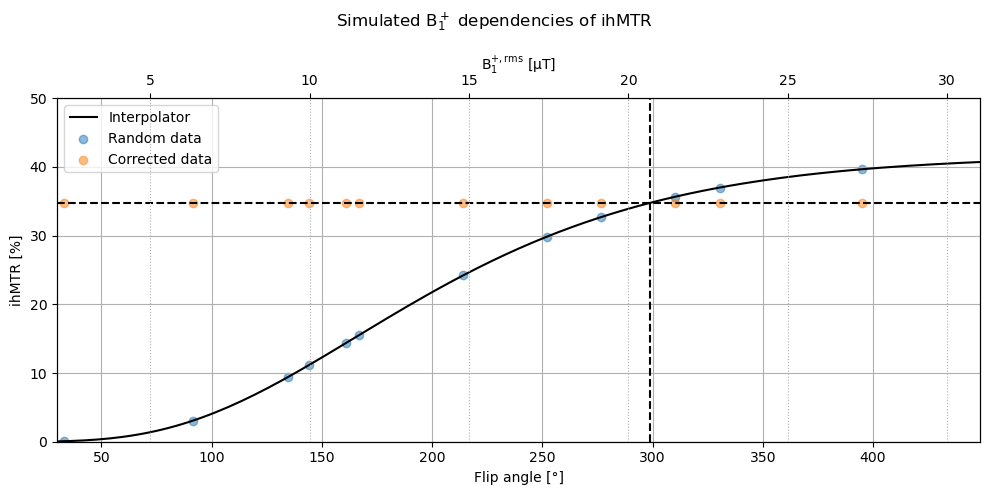

In [30]:
# 1D plotting of ihMTR = f(B1+)
x = corrector.ranges['flipAngle']
xb = (x / corrector.simulator.pulse.flipAngle) * simulator.pulse.b1RMS

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(x, ihMTR_values,'k', label=f'Interpolator')

ax.scatter(FA.flatten(), fake_data[Signal.ihMTR_CM].flatten(), label='Random data', alpha=.5)
ax.scatter(FA.flatten(), corrected[Signal.ihMTR_CM].flatten(), label='Corrected data', alpha=.5)

ax.vlines(corrector.simulator.pulse.flipAngle, 0, 50, 'k', 'dashed')
ax.hlines(corrector.nominals[Signal.ihMTR_CM], min(x), max(x), 'k', 'dashed')

ax.set_xlabel('Flip angle [°]')
ax.set_xlim(min(x), max(x))
ax.set_ylim(0, 50)
ax.set_ylabel('ihMTR [%]')

ax.legend()
ax.grid()

fig.suptitle(r'Simulated $\mathrm{B}_1^+$ dependencies of ihMTR')

ax2 = ax.twiny()
ax2.set_xlim(min(xb) * 1e6, max(xb) * 1e6)
ax2.set_xlabel(r'$\mathrm{B}_1^\mathrm{+,rms}$ [µT]')
ax2.grid(linestyle='dotted')

fig.tight_layout()
plt.show()

#### <a id='toc3_3_1_2_'></a>[N-Dim $\mathrm{B}_1^+$ correction](#toc0_)

In [31]:
##### Create the data

# Create an N-Dim corrector and retrieve the ihMTR_CM interpolant
nd_corrector = Corrector(simulator, {'poolFree_T1': np.array([.5, 1., 2., 4, 6, 8.]), 'flipAngle': simulator.pulse.flipAngle * np.linspace(.1, 1.5, 141)})
nominals = nd_corrector.nominals
interp = nd_corrector.interpolants[Signal.ihMTR_CM]

# Some fine tuning for the plot
test_interpolate_for_T1 = 1.25
x = nd_corrector.mesh['flipAngle'].T.squeeze()
ranges = np.vstack([test_interpolate_for_T1 * np.ones_like(x), x]).T

# Creating fake data to correct
shape = (5, 5, 5)
T1 = np.random.random(shape) * (max(nd_corrector.ranges['poolFree_T1']) - min(nd_corrector.ranges['poolFree_T1'])) + min(nd_corrector.ranges['poolFree_T1'])
B1 = np.random.random(shape) * (max(nd_corrector.ranges['flipAngle']) - min(nd_corrector.ranges['flipAngle'])) + min(nd_corrector.ranges['flipAngle'])
params = {'flipAngle': B1, 'poolFree_T1': T1}
data = {Signal.ihMTR_CM: interp(np.vstack([T1.flatten(), B1.flatten()]).T).reshape(shape)}
corrected = nd_corrector.apply(params, data)

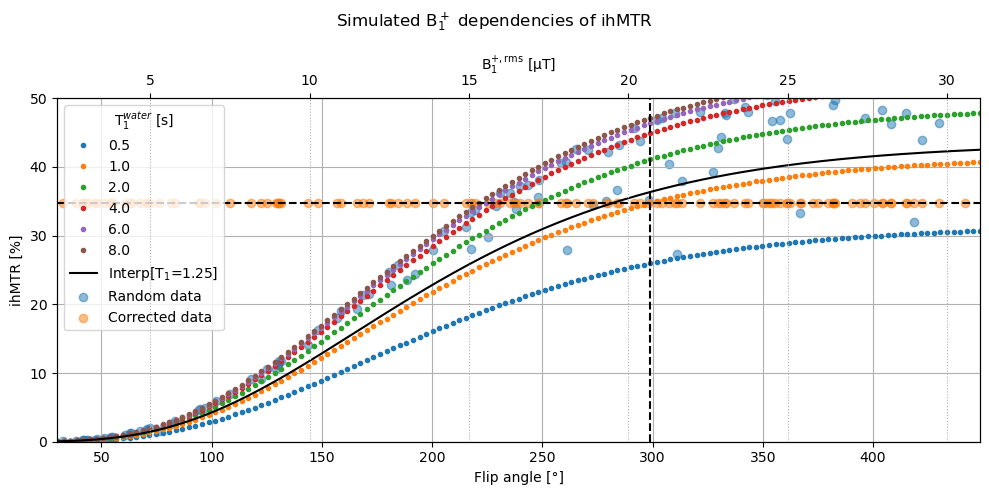

In [32]:
##### Visualize the results

# 2D plotting of ihMTR = f(B1+) for various values of T1_water
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(x, nd_corrector.simulated[Signal.ihMTR_CM].T, '.', label=nd_corrector.ranges['poolFree_T1'])
ax.plot(x, interp(ranges), color='k', label=r'Interp[$\mathrm{T}_1$=' + f'{test_interpolate_for_T1}]')

ax.scatter(B1.flatten(), data[Signal.ihMTR_CM].flatten(), label='Random data', alpha=.5)
ax.scatter(B1.flatten(), corrected[Signal.ihMTR_CM].flatten(), label='Corrected data', alpha=.5)

ax.vlines(simulator.pulse.flipAngle, 0, 50, 'k', 'dashed')
ax.hlines(nominals[Signal.ihMTR_CM], min(nd_corrector.ranges['flipAngle']), max(nd_corrector.ranges['flipAngle']), 'k', 'dashed')

ax.legend(title=r'$\mathrm{T}_1^{water}$ [s]')
ax.set_xlabel('Flip angle [°]')
ax.set_xlim(min(nd_corrector.ranges['flipAngle']), max(nd_corrector.ranges['flipAngle']))

ax.set_ylim(0, 50)
ax.set_ylabel('ihMTR [%]')

ax.grid()

ax2 = ax.twiny()
ax2.set_xlim(.1e6 * simulator.pulse.b1RMS, 1.5e6 * simulator.pulse.b1RMS)
ax2.set_xlabel(r'$\mathrm{B}_1^\mathrm{+,rms}$ [µT]')
ax2.grid(linestyle='dotted')

fig.suptitle(r'Simulated $\mathrm{B}_1^+$ dependencies of ihMTR')
fig.tight_layout()
plt.show()

#### <a id='toc3_3_1_3_'></a>[Real-world data](#toc0_)

In [33]:
# Preparing variables for correction of real-world data
with open('./examples/example_data_config.yaml') as file:
    real_conf = ya.safe_load(file)

real_pulse = Tukey(**real_conf['pulse'])
real_seq = Sequence(Signal.ihMTR_CM, real_pulse, **real_conf['sequence'])
real_sys = System(real_pulse, **real_conf['system'])
real_sim = Simulator(real_sys, real_seq, export_readMatrix=False, output_vectorSlice=slice(1))

real_data = sp.io.loadmat('./examples/example_data.mat')
real_params = {
    'axial'   : {
        'mask'       : real_data['axial']['mask'][0, 0],
        'flipAngle'  : real_data['axial']['flipAngle'][0, 0],
        'poolFree_T1': real_data['axial']['poolFree_T1'][0, 0],
    },
    'sagittal': {
        'mask'       : real_data['sagittal']['mask'][0, 0],
        'flipAngle'  : real_data['sagittal']['flipAngle'][0, 0],
        'poolFree_T1': real_data['sagittal']['poolFree_T1'][0, 0],
    },
    'coronal' : {
        'mask'       : real_data['coronal']['mask'][0, 0],
        'flipAngle'  : real_data['coronal']['flipAngle'][0, 0],
        'poolFree_T1': real_data['coronal']['poolFree_T1'][0, 0],
    },
}
real_ihMTR = {
    'axial'   : {Signal.ihMTR_CM: real_data['axial']['ihMTR_CM'][0, 0]},
    'sagittal': {Signal.ihMTR_CM: real_data['sagittal']['ihMTR_CM'][0, 0]},
    'coronal' : {Signal.ihMTR_CM: real_data['coronal']['ihMTR_CM'][0, 0]},
}

real_cor1D = Corrector.Simple(real_sim)
real_cor2D = Corrector(real_sim, ranges={'flipAngle': real_pulse.flipAngle * np.linspace(.1, 1.5, 141), 'poolFree_T1': np.arange(1, 4102, 100)})

real_axial    = real_cor1D.apply(real_params['axial'], real_ihMTR['axial'])
real_sagittal = real_cor1D.apply(real_params['sagittal'], real_ihMTR['sagittal'])
real_coronal  = real_cor1D.apply(real_params['coronal'], real_ihMTR['coronal'])

real_cor1D_data = {
    'axial'   : real_axial,
    'sagittal': real_sagittal,
    'coronal' : real_coronal,
}

real_axial    = real_cor2D.apply(real_params['axial'], real_ihMTR['axial'])
real_sagittal = real_cor2D.apply(real_params['sagittal'], real_ihMTR['sagittal'])
real_coronal  = real_cor2D.apply(real_params['coronal'], real_ihMTR['coronal'])

real_cor2D_data = {
    'axial'   : real_axial,
    'sagittal': real_sagittal,
    'coronal' : real_coronal,
}

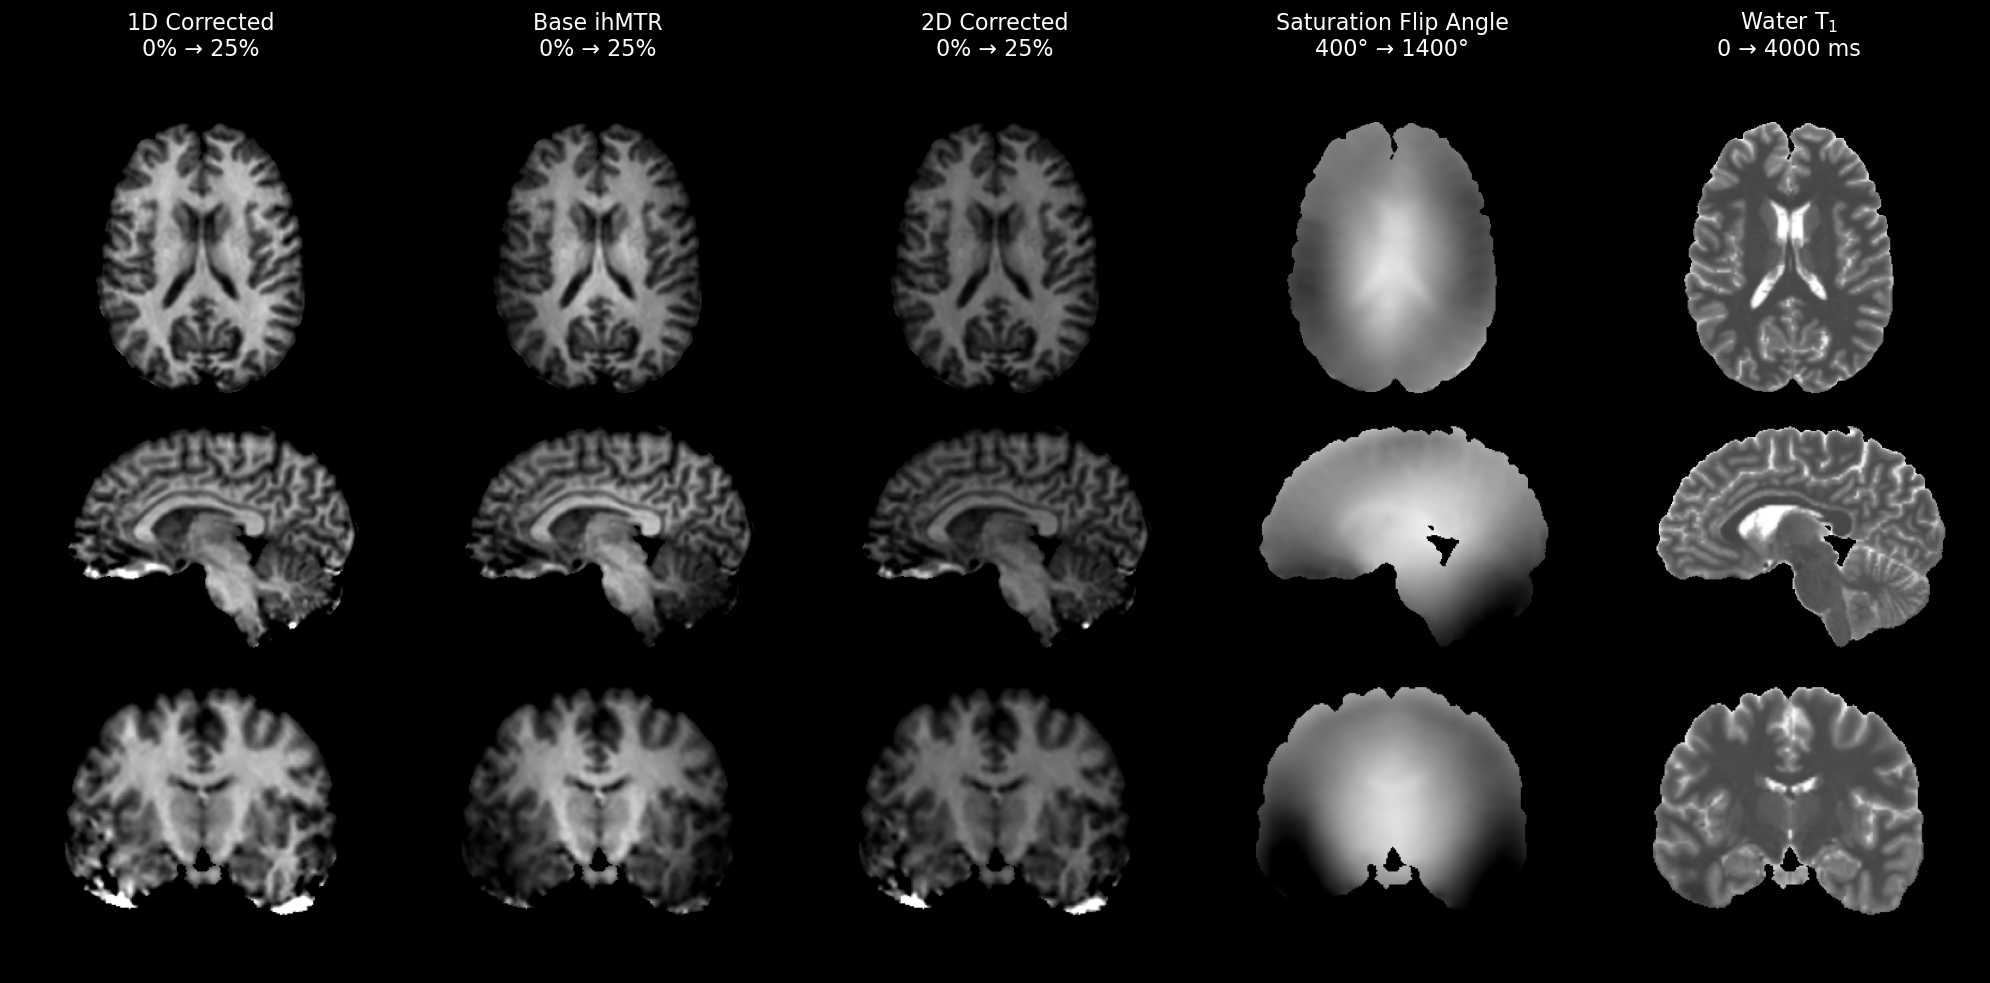

In [34]:
fig, ax = plt.subplots(3, 5, figsize=(20, 10), facecolor='k')
ax = ax.flatten()

c0_0 = ax[0 + 0].imshow(real_cor1D_data['axial'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c0_1 = ax[0 + 1].imshow(real_ihMTR['axial'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c0_2 = ax[0 + 2].imshow(real_cor2D_data['axial'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c0_3 = ax[0 + 3].imshow(real_params['axial']['flipAngle'], cmap='gray', vmin=450, vmax=1400)
c0_4 = ax[0 + 4].imshow(real_params['axial']['poolFree_T1'], cmap='gray', vmin=0, vmax=4000)

c5_0 = ax[5 + 0].imshow(real_cor1D_data['sagittal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c5_1 = ax[5 + 1].imshow(real_ihMTR['sagittal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c5_2 = ax[5 + 2].imshow(real_cor2D_data['sagittal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c5_3 = ax[5 + 3].imshow(real_params['sagittal']['flipAngle'], cmap='gray', vmin=450, vmax=1400)
c5_4 = ax[5 + 4].imshow(real_params['sagittal']['poolFree_T1'], cmap='gray', vmin=0, vmax=4000)

c10_0 = ax[10 + 0].imshow(real_cor1D_data['coronal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c10_1 = ax[10 + 1].imshow(real_ihMTR['coronal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c10_2 = ax[10 + 2].imshow(real_cor2D_data['coronal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c1032 = ax[10 + 3].imshow(real_params['coronal']['flipAngle'], cmap='gray', vmin=450, vmax=1400)
c1042 = ax[10 + 4].imshow(real_params['coronal']['poolFree_T1'], cmap='gray', vmin=0, vmax=4000)

ax[0 + 0].set_title('1D Corrected\n0% → 25%', color='white', fontsize=16)
ax[0 + 1].set_title('Base ihMTR\n0% → 25%'.center(12), color='white', fontsize=16)
ax[0 + 2].set_title('2D Corrected\n0% → 25%', color='white', fontsize=16)
ax[0 + 3].set_title('Saturation Flip Angle\n400° → 1400°'.center(12), color='white', fontsize=16)
ax[0 + 4].set_title(r'Water $\mathrm{T}_1$' '\n0 → 4000 ms'.center(12), color='white', fontsize=16)

[axis.axis('off') for axis in ax]

fig.subplots_adjust(wspace=None, hspace=-.4)
fig.tight_layout()
plt.show()

### <a id='toc3_3_2_'></a>[Example: Steady-state signal with respect to readout](#toc0_)

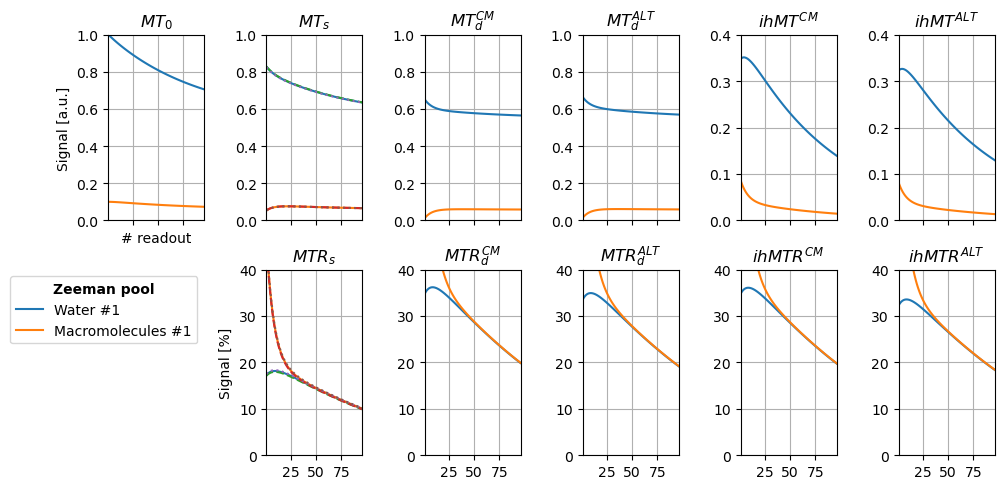

In [35]:
# Generating the data
# pulse = Tukey(duration=1.5e-3, shape=.3, flipAngle=299, offset=7000)
# system = System(pulse=pulse, poolFree_M0=1, poolFree_T1=2, poolFree_T2=5e-3, poolFreeBound_exchangeRate=[60, 10], poolBound_M0=[.6, .4], poolBound_T1=[1, .3], poolBound_T2=[10e-6, 10e-6], poolBound_T1D=[20e-3, 5e-3], poolBound_lineshapeAsymmetry=[600, 600])
# sequence = Sequence(signal=Signal.ALL, pulse=pulse, N_pulsePerOffset=1, N_pulse=4, N_burst=10, N_adc=80, N_dummyADC=0, dt_interPulse=1.5e-3, TR_burst=90e-3, dt_lastBurst=7e-3, es=7e-3, tr=1.5, readout_flipAngle=5)
# simulator = Simulator(system=system, sequence=sequence, output_vectorSlice=slice(None), export_readMatrix=True)
# readouts = Trajector.readouts(simulator=simulator, stable=True)

# Generating the visuals
x = np.array(range(1, simulator.sequence.N_adc + 1))
slices = [0] + list(range(1, len(readouts[Signal.MT0]) - 1, 2))  # Show Zeeman Water and Zeeman Macromolecules only

with np.errstate(divide='ignore', invalid='ignore'):
    fig, axes = plt.subplots(2, 6, sharex=True, figsize=(10, 5))
    axes = axes.flatten()

    axes[0].set_title("$MT_0$")
    axes[0].grid()
    axes[0].set_ylim(0, 1)
    lines = axes[0].plot(x, readouts[Signal.MT0][slices, :].T)
    axes[0].set_xlim(1, simulator.sequence.N_adc)
    axes[0].set_xlabel('# readout')
    axes[0].set_ylabel('Signal [a.u.]')
    axes[0 + 6].set_axis_off()

    axes[1].set_title("$MT_s$")
    axes[1].grid()
    axes[1].set_ylim(0, 1)
    axes[1].plot(x, readouts[Signal.MTs][slices, :].T, linestyle='solid')
    axes[1].plot(x, readouts[Signal.MTs_Positive][slices, :].T, linestyle='dashed')
    axes[1].plot(x, readouts[Signal.MTs_Negative][slices, :].T, linestyle='dotted')
    axes[1 + 6].set_title("$MTR_s$")
    axes[1 + 6].grid()
    axes[1 + 6].set_ylim(0, 40)
    axes[1 + 6].set_ylabel('Signal [%]')
    axes[1 + 6].plot(x, readouts[Signal.MTsR][slices, :].T, linestyle='solid')
    axes[1 + 6].plot(x, readouts[Signal.MTsR_Positive][slices, :].T, linestyle='dashed')
    axes[1 + 6].plot(x, readouts[Signal.MTsR_Negative][slices, :].T, linestyle='dotted')

    axes[2].set_title("$MT_d^{CM}$")
    axes[2].grid()
    axes[2].set_ylim(0, 1)
    axes[2].plot(x, readouts[Signal.MTd_CM][slices, :].T)
    axes[2 + 6].set_title("$MTR_d^{CM}$")
    axes[2 + 6].grid()
    axes[2 + 6].set_ylim(0, 40)
    axes[2 + 6].plot(x, readouts[Signal.MTdR_CM][slices, :].T)

    axes[3].set_title("$MT_d^{ALT}$")
    axes[3].grid()
    axes[3].set_ylim(0, 1)
    axes[3].plot(x, readouts[Signal.MTd_ALT][slices, :].T)
    axes[3 + 6].set_title("$MTR_d^{ALT}$")
    axes[3 + 6].grid()
    axes[3 + 6].set_ylim(0, 40)
    axes[3 + 6].plot(x, readouts[Signal.MTdR_ALT][slices, :].T)

    axes[4].set_title("$ihMT^{CM}$")
    axes[4].grid()
    axes[4].set_ylim(0, .40)
    axes[4].plot(x, readouts[Signal.ihMT_CM][slices, :].T)
    axes[4 + 6].set_title("$ihMTR^{CM}$")
    axes[4 + 6].grid()
    axes[4 + 6].set_ylim(0, 40)
    axes[4 + 6].plot(x, readouts[Signal.ihMTR_CM][slices, :].T)

    axes[5].set_title("$ihMT^{ALT}$")
    axes[5].grid()
    axes[5].set_ylim(0, .40)
    axes[5].plot(x, readouts[Signal.ihMT_ALT][slices, :].T)
    axes[5 + 6].set_title("$ihMTR^{ALT}$")
    axes[5 + 6].grid()
    axes[5 + 6].set_ylim(0, 40)
    axes[5 + 6].plot(x, readouts[Signal.ihMTR_ALT][slices, :].T)

    axes[0 + 6].legend(handles=lines, labels=[*[f'Water #{i+1}' for i in range(simulator.system.N_poolFree)], *[f'Macromolecules #{i+1}' for i in range(simulator.system.N_poolBound)]], title='Zeeman pool', title_fontproperties={'weight':'bold'})
    plt.tight_layout()
    plt.show()

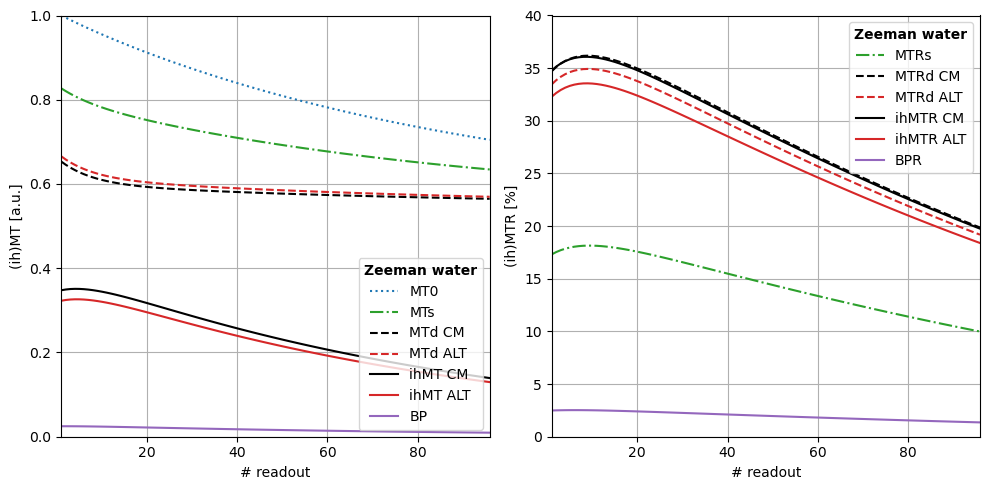

In [36]:
# Generating the data
readouts = Trajector.readouts(simulator=simulator, stable=True)

# Generating the visuals
x = np.array(range(1, simulator.sequence.N_adc + 1))
slices = slice(0, 2)  # Show Zeeman Water and Zeeman Macromolecules only

with np.errstate(divide='ignore', invalid='ignore'):
    fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 5))
    axes = axes.flatten()

    axes[0].plot(x, readouts[Signal.MT0][0], color='C0', linestyle='dotted', label='MT0')
    axes[0].plot(x, readouts[Signal.MTs][0], color='C2', linestyle='-.', label='MTs')
    axes[0].plot(x, readouts[Signal.MTd_CM][0], color='k', linestyle='--', label='MTd CM')
    axes[0].plot(x, readouts[Signal.MTd_ALT][0], color='C3', linestyle='--', label='MTd ALT')
    axes[0].plot(x, readouts[Signal.ihMT_CM][0], color='k', linestyle='-', label='ihMT CM')
    axes[0].plot(x, readouts[Signal.ihMT_ALT][0], color='C3', linestyle='-', label='ihMT ALT')
    axes[0].plot(x, readouts[Signal.BP][0], color='C4', linestyle='-', label='BP')

    axes[1].plot(x, readouts[Signal.MTsR][0], color='C2', linestyle='-.', label='MTRs')
    axes[1].plot(x, readouts[Signal.MTdR_CM][0], color='k', linestyle='--', label='MTRd CM')
    axes[1].plot(x, readouts[Signal.MTdR_ALT][0], color='C3', linestyle='--', label='MTRd ALT')
    axes[1].plot(x, readouts[Signal.ihMTR_CM][0], color='k', linestyle='-', label='ihMTR CM')
    axes[1].plot(x, readouts[Signal.ihMTR_ALT][0], color='C3', linestyle='-', label='ihMTR ALT')
    axes[1].plot(x, readouts[Signal.BPR][0], color='C4', linestyle='-', label='BPR')

    axes[0].legend(title='Zeeman water', title_fontproperties={'weight':'bold'}, loc='lower right')
    axes[0].grid()
    axes[0].set_xlabel('# readout')
    axes[0].set_xlim(1, simulator.sequence.N_adc)
    axes[0].set_ylabel('(ih)MT [a.u.]')
    axes[0].set_ylim(0, 1)

    axes[1].legend(title='Zeeman water', title_fontproperties={'weight':'bold'}, loc='upper right')
    axes[1].grid()
    axes[1].set_xlabel('# readout')
    axes[1].set_xlim(1, simulator.sequence.N_adc)
    axes[1].set_ylabel('(ih)MTR [%]')
    axes[1].set_ylim(0, 40)

    plt.tight_layout()
    plt.show()

### <a id='toc3_3_3_'></a>[Exmple: PSF - WIP](#toc0_)

## <a id='toc3_4_'></a>[Advanced](#toc0_)

### <a id='toc3_4_1_'></a>[Sensivity analysis - WIP](#toc0_)

#### <a id='toc3_4_1_1_'></a>[Using fixed parameter vectors](#toc0_)

#### <a id='toc3_4_1_2_'></a>[Using distribution sampling](#toc0_)

# <a id='toc4_'></a>[Additional Information](#toc0_)

## <a id='toc4_1_'></a>[Configuration files](#toc0_)

### <a id='toc4_1_1_'></a>[Default configurations](#toc0_)

#### <a id='toc4_1_1_1_'></a>[3 Teslas](#toc0_)

In [37]:
for key, val in default.items():
    print(f'\033[1m{key}\033[0m')
    for kkey, vval in val.items():
        if type(vval) != dict:
            print(str(kkey).rjust(len('poolBound_lineshapeAsymmetry')), ':', repr(vval))
        else:
            print(f'\t\033[1m{kkey}\033[0m')
            for kkkey, vvval in vval.items():
                print('\t\t', kkkey, repr(vvval))
    print()

run
                          pw : 0.001
                     r_tukey : 0.3
                      fa_sat : 200
                      offset : 7000
                 FLAG_Signal : 'ALL'
                    N_altern : 1
                          np : 4
                          nb : 10
                       turbo : 80
                  N_dummyADC : 3
                          dt : 0.0015
                         btr : 0.1
                     btrlast : 0.001
                          es : 0.006
                          tr : 3
                     fa_rage : 5
                         M0a : 1
                         M0b : 0.1
                         T1f : 1
                         T2f : 0.1
                         T1b : 1
                         T1D : 0.01
                         T2b : 1e-05
                           R : 10
poolBound_lineshapeAsymmetry : -593.83
                 export_read : True
           output_fullVector : True
                   outputDir : './output/'
      

#### <a id='toc4_1_1_2_'></a>[7 Teslas](#toc0_)

### <a id='toc4_1_2_'></a>[Custom configurations](#toc0_)

#### <a id='toc4_1_2_1_'></a>[In a live environment](#toc0_)

#### <a id='toc4_1_2_2_'></a>[Stored on file](#toc0_)

## <a id='toc4_2_'></a>[Loggers](#toc0_)

## <a id='toc4_3_'></a>[The `brainhack.meta.CompositeDictionary` class](#toc0_)

## <a id='toc4_4_'></a>[Optimizing `brainhack.run.GridRuns` runtime](#toc0_)

## <a id='toc4_5_'></a>[Test suite](#toc0_)


In [38]:
try:
    import coverage
except ImportError as e:
    %pip install coverage

!./run_tests.sh

.ss....................................................s.............................
----------------------------------------------------------------------
Ran 85 tests in 4.160s

OK (skipped=3)
Wrote HTML report to ]8;;file:///home/tanderson/git/brainhack/htmlcov/index.htmlhtmlcov/index.html]8;;
Name                     Stmts   Miss Branch BrPart  Cover
----------------------------------------------------------
brainhack/__init__.py        8      0      0      0   100%
brainhack/config.py         24      4      2      0    85%
brainhack/corrector.py     114     76     40      0    25%
brainhack/meta.py          419    207    174     25    45%
brainhack/pulse.py         179     25     20      0    85%
brainhack/run.py            95     60     38      1    29%
brainhack/sequence.py      222     11     28      8    92%
brainhack/simulator.py     127     17     30     10    82%
brainhack/system.py        344     35     46      7    89%
brainhack/trajector.py      59     29     10    

## <a id='toc4_6_'></a>[Contributing new features - WIP](#toc0_)

### <a id='toc4_6_1_'></a>[Adding new modules](#toc0_)

### <a id='toc4_6_2_'></a>[Modifying existing modules](#toc0_)

# <a id='toc5_'></a>[Notes](#toc0_)

- General nomenclature (variable, function, class, and file names) is still open to changes
- Parameter names of `brainhack.run.SingleRun` should match exactly the names in `config` files/dict for `SingleRun(**config)` to work as intended
- new python projects tend to favor `.toml` over `.yaml` configuration files, but I'm not too sure if the switch is worth it
    - A generic `Configuration` object could be implemented and instantiated with `Configuration.from_yaml`, `Configuration.from_toml`, and `Configuration.from_json`

# <a id='toc6_'></a>[To do](#toc0_)

1. <span style='color:red'>Generic - Improve test coverage (currently: 65%, goal: >95%)</span>
3. <span style='color:orange'>Notebook - Detail how-tos</span>
3. <span style='color:orange'>Generic - Increase logging</span>
4. <span style='color:yellow'>Trajector - Implement various default trajectory and generic trajectory</span>
5. <span style='color:yellow'>Trajector - Implement PSF and related</span>
6. <span style='color:green'>Simulator - Solver choice</span>
7. <span style='color:green'>Simulator - Step by step solver</span>
7. <span style='color:green'>Sequence - Add dummy TR attribute</span>
7. <span style='color:green'>Trajector - Use Step by step solver for readouts at every k-space sample point</span>
8. Generic - Numba / Cython